Beta regression on World Bank Gini index (WDI)

The base model is a **beta regression** to an inequality outcome (**Gini index**) fitted by **maximum likelihood**, with a **logit link for the mean** and **constant precision** (i.e., the “scale/precision” submodel has only an intercept).

We use the attached, already-prepared dataset `reg_df.csv` (exported from R/WDI).


In [1]:
# Core numerics + optimization
import numpy as np
import pandas as pd

from scipy.optimize import minimize
from scipy.special import expit, gammaln

# Display helpers
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)


The file `reg_df.csv` is a **country–year panel** assembled from the World Bank's World Development Indicators (WDI), using R's `WDI` package, then cleaned for beta regression.

Each row is one `(country, year)` observation.


- `y_adj` (**response**, used in modeling):  
  The **Gini index** (originally on 0–100 scale in WDI) converted to a proportion in (0, 1), then “squeezed” into the open interval (0, 1) using the Smithson–Verkuilen adjustment  
  \[
  y_{adj} = \frac{y(n-1) + 0.5}{n}, \quad y \in (0,1)
  \]
  where `n` is the number of rows in the regression dataset.

- `year`: calendar year.

- `iso3c`: ISO-3 country code.

- `country`: country name.

- `region`: World Bank region label (categorical).

- `income`: World Bank income group label (categorical).

- `log_gdppc`: log of GDP per capita (constant USD), i.e. `log(NY.GDP.PCAP.KD)`.

- `urban`: urban population (% of total), `SP.URB.TOTL.IN.ZS`.

- `unemp`: unemployment rate (% of total labor force), `SL.UEM.TOTL.ZS`.

- `trade`: trade openness (% of GDP), `NE.TRD.GNFS.ZS`.

In [2]:
# Load the prepared dataset
csv_path = r"reg_df.csv"
df = pd.read_csv(csv_path)

# Drop the leftover index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()


,y_adj,year,iso3c,country,region,income,log_gdppc,urban,unemp,trade
0,0.270104,1996,ALB,Albania,Europe & Central Asia,Upper middle income,7.428790,38.899604,13.928,44.411782
1,0.306088,2005,ALB,Albania,Europe & Central Asia,Upper middle income,7.905762,45.993767,15.966,69.116293
2,0.290095,2012,ALB,Albania,Europe & Central Asia,Upper middle income,8.235320,53.863755,13.376,76.968358
3,0.294093,2020,ALB,Albania,Europe & Central Asia,Upper middle income,8.513309,57.140859,11.690,59.520699
4,0.301090,2019,ALB,Albania,Europe & Central Asia,Upper middle income,8.531577,56.763907,11.466,75.382129


The preprocessing was performed in R (using WDI + dplyr) and resulted in this CSV. The key steps were:

1. **Remove aggregates**: keep only actual countries (`region != "Aggregates"`).
2. **Keep the study window**: start around 1990+.
3. **Construct Gini proportion**: `y = gini / 100`.
4. **Ensure open-interval support**: keep `0 < y < 1`.
5. **(Optional but safe) Smithson–Verkuilen adjustment** to keep values strictly inside (0,1):  
   \[
   y_{adj} = \frac{y(n-1) + 0.5}{n}
   \]
6. **Create covariates** like `log_gdppc = log(gdp_pc)`.
7. **Drop rows missing any predictors used in the regression**.


Note: In the modeling that follows, we use only **numerical covariates** — `log_gdppc`, `urban`, `unemp`, `trade`, and `year`.

In [3]:
# Basic shape and missingness
print("Rows, columns:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum())

# Response sanity: must be strictly in (0,1)
y = df["y_adj"].to_numpy()
print("\nResponse y_adj summary:")
display(df["y_adj"].describe())
print("All y_adj in (0,1):", bool(np.all((y > 0) & (y < 1))))

# Quick summaries of predictors
display(df[["log_gdppc", "urban", "unemp", "trade", "year"]].describe())


Rows, columns: (2093, 10)

Missing values per column:


y_adj        0
year         0
iso3c        0
country      0
region       0
income       0
log_gdppc    0
urban        0
unemp        0
trade        0
dtype: int64


Response y_adj summary:


count    2093.000000
mean        0.372702
std         0.086239
min         0.202135
25%         0.308087
50%         0.352067
75%         0.424034
max         0.710905
Name: y_adj, dtype: float64

All y_adj in (0,1): True


,log_gdppc,urban,unemp,trade,year
count,2093.000000,2093.000000,2093.000000,2093.000000,2093.000000
mean,9.023439,64.636338,7.969599,85.885467,2009.182035
std,1.327749,18.481512,5.268500,49.086626,8.588301
min,5.425824,10.215852,0.140000,13.753054,1991.000000
25%,8.111073,54.382847,4.415000,52.693370,2003.000000
50%,9.012798,67.353879,6.700000,74.590296,2010.000000
75%,10.199848,78.478536,10.212000,107.619709,2016.000000
max,11.629978,99.031013,37.320000,412.177170,2024.000000


A beta regression is fitted:

- **Mean submodel**: logit link  
  $
  \text{logit}(\mu_i) = x_i^\top \beta
  $
- **Precision** (a.k.a. “scale”) **constant** across observations  
  $
  \log(\phi) = \alpha_0
  $
- **Likelihood**  
  $
  y_i \sim \text{Beta}(a_i, b_i), \quad a_i = \mu_i\phi,\; b_i=(1-\mu_i)\phi
  $


In [4]:
# Build the design matrix for the mean model:
#   Intercept + continuous covariates + year (continuous-only)
# Constant precision: only one parameter log_phi.

cont_cols = ["log_gdppc", "urban", "unemp", "trade", "year"]

X_cont = df[cont_cols].copy()

# Continuous-only design; no categorical dummies
X = X_cont.copy()
X.insert(0, "Intercept", 1.0)

y = df["y_adj"].to_numpy(dtype=float)
X_mat = X.to_numpy(dtype=float)

print("Design matrix shape:", X_mat.shape)
print("Number of parameters in mean model (beta):", X_mat.shape[1])

# 90/10 train-test split (deterministic)
n = X_mat.shape[0]
rng = np.random.default_rng(123)
perm = rng.permutation(n)
n_train = int(0.9 * n)
train_idx = perm[:n_train]
test_idx = perm[n_train:]

X_mat_train = X_mat[train_idx]
X_mat_test = X_mat[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)
X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)

print(f"Train size: {len(train_idx)}, Test size: {len(test_idx)}")


Design matrix shape: (2093, 6)
Number of parameters in mean model (beta): 6
Train size: 1883, Test size: 210


Maximum-likelihood fitting (manual beta regression)


For observation \(i\):

- \(\mu_i = \text{logit}^{-1}(x_i^\top\beta)\)
- \(\phi = \exp(\text{log\_phi})\) (constant)

Then:

\[
\ell_i(\beta,\phi) =
\log \Gamma(\phi) - \log \Gamma(\mu_i\phi) - \log \Gamma((1-\mu_i)\phi)
+ (\mu_i\phi - 1)\log y_i + ((1-\mu_i)\phi - 1)\log(1-y_i)
\]



In [5]:
def neg_loglik(params, y, X):
    """Negative log-likelihood for beta regression with logit mean and constant precision.

    params = [beta_0, ..., beta_{p-1}, log_phi]
    """
    beta = params[:-1]
    log_phi = params[-1]
    phi = np.exp(log_phi)

    eta = X @ beta
    mu = expit(eta)

    # beta distribution parameters
    a = mu * phi
    b = (1 - mu) * phi

    # log-likelihood (vectorized)
    ll = (
        gammaln(phi) - gammaln(a) - gammaln(b)
        + (a - 1) * np.log(y)
        + (b - 1) * np.log(1 - y)
    )

    return -np.sum(ll)


# Initial parameters
p = X_mat_train.shape[1]
init = np.zeros(p + 1)   # betas + log_phi
init[-1] = 0.0           # log_phi -> phi=1 start

res = minimize(
    neg_loglik,
    init,
    args=(y_train, X_mat_train),
    method="BFGS",
    options={"disp": True, "maxiter": 500}
 )

print("\nConverged:", res.success)
print("Message:", res.message)
print("Final negative log-likelihood (train):", res.fun)

         Current function value: -2253.730053
         Iterations: 19
         Function evaluations: 566
         Gradient evaluations: 68

Converged: False
Message: Desired error not necessarily achieved due to precision loss.
Final negative log-likelihood (train): -2253.7300527914567


/Users/zichuanchen/miniconda3/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/Users/zichuanchen/miniconda3/lib/python3.13/site-packages/scipy/optimize/_minimize.py:780: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


Report coefficients (mean model) and constant precision


In [6]:
beta_hat = res.x[:-1]
log_phi_hat = res.x[-1]
phi_hat = float(np.exp(log_phi_hat))

# Approximate covariance from inverse Hessian
# (BFGS returns an approximation to the inverse Hessian)
Hinv = np.asarray(res.hess_inv)
se = np.sqrt(np.diag(Hinv))

param_names = list(X.columns) + ["log_phi"]
est = np.r_[beta_hat, log_phi_hat]

out = pd.DataFrame({
    "param": param_names,
    "estimate": est,
    "std_err": se,
    "z": est / se
})

# Convert log_phi -> phi for readability
phi_row = pd.DataFrame({
    "param": ["phi (precision)"],
    "estimate": [phi_hat],
    "std_err": [np.nan],
    "z": [np.nan]
})

display(out.head(15))
display(phi_row)


,param,estimate,std_err,z
0,Intercept,11.917745,1.767378,6.743177
1,log_gdppc,-0.149342,0.009666,-15.450671
2,urban,0.006662,0.000649,10.270690
3,unemp,-0.002502,0.001467,-1.705310
4,trade,-0.001296,0.000168,-7.727630
5,year,-0.005670,0.000882,-6.424763
6,log_phi,3.741608,0.033106,113.019800


,param,estimate,std_err,z
0,phi (precision),42.165718,NaN,NaN


Fitted means and a quick calibration check

In [7]:
# Fitted means on train and test, plus quick calibration on TEST
mu_hat_train = expit(X_mat_train @ beta_hat)
mu_hat_test = expit(X_mat_test @ beta_hat)

df_train = df_train.copy()
df_test = df_test.copy()
df_train["mu_hat"] = mu_hat_train
df_test["mu_hat"] = mu_hat_test

# Quick summaries on test set
display(df_test[["y_adj", "mu_hat"]].describe())

# Simple predictive error summaries on TEST
err = df_test["y_adj"] - df_test["mu_hat"]
print("TEST MAE:", float(np.mean(np.abs(err))))
print("TEST RMSE:", float(np.sqrt(np.mean(err**2))))

# Show a few test rows
display(df_test[["country", "iso3c", "year", "y_adj", "mu_hat", "region", "income"]].head(10))

,y_adj,mu_hat
count,210.000000,210.000000
mean,0.372082,0.373940
std,0.087536,0.037205
min,0.240117,0.239373
25%,0.308587,0.346490
50%,0.351067,0.378539
75%,0.422535,0.402039
max,0.647933,0.444669


TEST MAE: 0.06216809598876995
TEST RMSE: 0.07774836047123175


,country,iso3c,year,y_adj,mu_hat,region,income
0,Kazakhstan,KAZ,2002,0.348069,0.380337,Europe & Central Asia,Upper middle income
1,Costa Rica,CRI,1993,0.459019,0.385294,Latin America & Caribbean,Upper middle income
2,"Congo, Rep.",COG,2005,0.473012,0.403429,Sub-Saharan Africa,Lower middle income
3,Latvia,LVA,1996,0.316083,0.406473,Europe & Central Asia,High income
4,Bulgaria,BGR,2018,0.413039,0.363663,Europe & Central Asia,High income
5,Ecuador,ECU,2019,0.457019,0.382369,Latin America & Caribbean,Upper middle income
6,Eswatini,SWZ,2016,0.545979,0.321491,Sub-Saharan Africa,Lower middle income
7,Uruguay,URY,2006,0.459019,0.414785,Latin America & Caribbean,High income
8,Mexico,MEX,2012,0.496002,0.390163,Latin America & Caribbean,Upper middle income
9,Dominican Republic,DOM,2013,0.477010,0.402787,Latin America & Caribbean,Upper middle income


Visualizing Predictions

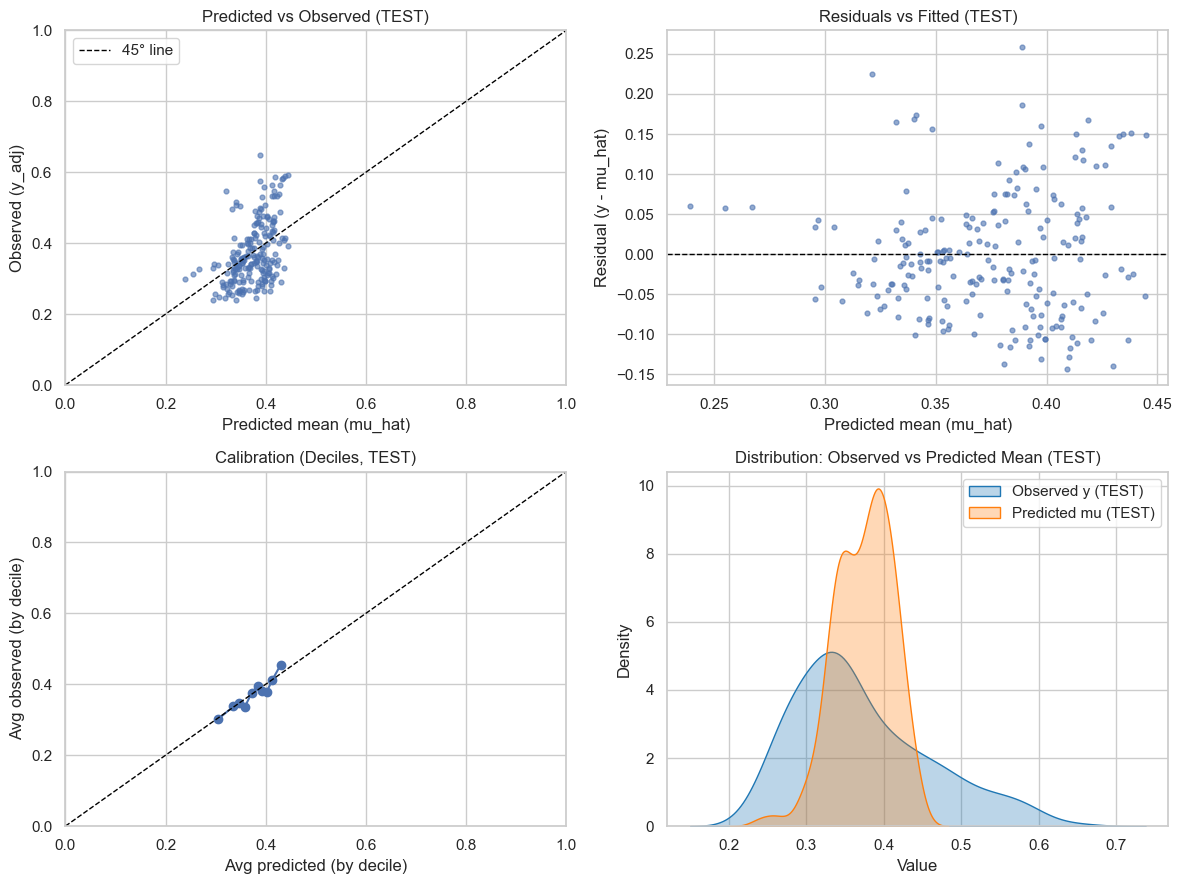

In [8]:
# Visualization of prediction results (TEST set only)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

assert "mu_hat" in df_test.columns and "y_adj" in df_test.columns, "Expected columns missing in df_test"

y_obs = df_test["y_adj"].to_numpy()
y_hat = df_test["mu_hat"].to_numpy()
resid = y_obs - y_hat

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1) Predicted vs Observed (TEST)
ax = axes[0, 0]
ax.scatter(y_hat, y_obs, s=12, alpha=0.6)
ax.plot([0, 1], [0, 1], color="black", lw=1, linestyle="--", label="45° line")
ax.set_xlabel("Predicted mean (mu_hat)")
ax.set_ylabel("Observed (y_adj)")
ax.set_title("Predicted vs Observed (TEST)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()

# 2) Residuals vs Fitted (TEST)
ax = axes[0, 1]
ax.scatter(y_hat, resid, s=12, alpha=0.6)
ax.axhline(0.0, color="black", lw=1, linestyle="--")
ax.set_xlabel("Predicted mean (mu_hat)")
ax.set_ylabel("Residual (y - mu_hat)")
ax.set_title("Residuals vs Fitted (TEST)")

# 3) Calibration by deciles (TEST)
ax = axes[1, 0]
bins = pd.qcut(y_hat, q=10, duplicates="drop")
calib = (df_test.assign(bin=bins)
         .groupby("bin", observed=True)
         .agg(mean_pred=("mu_hat", "mean"), mean_obs=("y_adj", "mean"))
         .reset_index(drop=True))
ax.plot(calib["mean_pred"], calib["mean_obs"], marker="o")
ax.plot([0, 1], [0, 1], color="black", lw=1, linestyle="--")
ax.set_xlabel("Avg predicted (by decile)")
ax.set_ylabel("Avg observed (by decile)")
ax.set_title("Calibration (Deciles, TEST)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# 4) Distribution overlay (TEST)
ax = axes[1, 1]
sns.kdeplot(y_obs, ax=ax, label="Observed y (TEST)", fill=True, alpha=0.3, color="#1f77b4", clip=(0,1))
sns.kdeplot(y_hat, ax=ax, label="Predicted mu (TEST)", fill=True, alpha=0.3, color="#ff7f0e", clip=(0,1))
ax.set_xlabel("Value")
ax.set_title("Distribution: Observed vs Predicted Mean (TEST)")
ax.legend()

plt.tight_layout()
plt.show()

Updated Model for GP Density Correction (Hyvärinen + Variational ELBO)

In [9]:
# Setup: PyTorch + helpers (updated model)
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from dataclasses import dataclass

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)
np.random.seed(0)

# Use only continuous predictors for the GP inputs (keeps ARD size reasonable)
gp_cols = ["log_gdppc", "urban", "unemp", "trade", "year"]
X_gp_train = df_train[gp_cols].copy()
X_gp_test = df_test[gp_cols].copy()
X_gp_all = df[gp_cols].copy()

# Min-max scale to [0,1] per-dimension using FULL data (train + test)
x_min = X_gp_all.min(axis=0)
x_max = X_gp_all.max(axis=0)
X_gp_scaled = (X_gp_train - x_min) / (x_max - x_min + 1e-12)
X_gp_scaled = X_gp_scaled.to_numpy(dtype=float)

# Base Beta parameters for each TRAIN row from the fitted model
mu_base_train = mu_hat_train   # from earlier cell
phi_base_original = phi_hat    # constant precision (original scale for visualization)

# Halve the beta precision to make the GPDR training base more diffuse.
PHI_SCALE_FACTOR = 0.5
phi_base = phi_base_original * PHI_SCALE_FACTOR

print(f"Original precision phi: {phi_base_original:.4f}")
print(f"Training precision phi (scaled by {PHI_SCALE_FACTOR}): {phi_base:.4f}")

a_base = mu_base_train * phi_base
b_base = (1.0 - mu_base_train) * phi_base

# Clamp y to open interval (TRAIN)
eps = 1e-6
y_np = np.clip(df_train["y_adj"].to_numpy(dtype=float), eps, 1.0 - eps)

# Torch tensors (TRAIN)
x_t = torch.from_numpy(X_gp_scaled)             # (n_train, d)
y_t = torch.from_numpy(y_np)                    # (n_train,)
a_t = torch.from_numpy(a_base)                  # (n_train,)
b_t = torch.from_numpy(b_base)                  # (n_train,)

def beta_pdf_torch(y, a, b):
    # y in (0,1). log pdf then exp for stability
    logB = torch.lgamma(a) + torch.lgamma(b) - torch.lgamma(a + b)
    logp = (a - 1.0) * torch.log(y) + (b - 1.0) * torch.log1p(-y) - logB
    return torch.exp(logp)

def beta_cdf_torch(y, a, b):
    # Torch lacks betainc; fallback to SciPy and convert back
    from scipy.special import betainc
    y_np = y.detach().cpu().numpy()
    a_np = a.detach().cpu().numpy()
    b_np = b.detach().cpu().numpy()
    cdf_np = betainc(a_np, b_np, y_np)
    return torch.from_numpy(cdf_np).to(y.dtype).to(y.device)

def beta_derivatives(y, a, b):
    # Closed-form derivatives wrt y:
    # d/dy log g = (a-1)/y - (b-1)/(1-y)
    # d2/dy2 log g = -(a-1)/y^2 - (b-1)/(1-y)^2
    g = beta_pdf_torch(y, a, b)
    dlog = (a - 1.0) / y - (b - 1.0) / (1.0 - y)
    d2log = -(a - 1.0) / (y**2) - (b - 1.0) / ((1.0 - y) ** 2)
    gy = g * dlog
    gyy = g * (dlog**2 + d2log)
    return g, gy, gyy

# Compute base terms and the z-transform (TRAIN)
with torch.no_grad():
    g_t, gy_t, gyy_t = beta_derivatives(y_t, a_t, b_t)
    z_t = torch.clamp(beta_cdf_torch(y_t, a_t, b_t), 1e-6, 1-1e-6)  # (n_train,)

# Build training inputs V = concat(x, z)
V_t = torch.cat([x_t, z_t.reshape(-1,1)], dim=1)  # (n_train, d+1)
n, d = x_t.shape
print(f"GP TRAIN inputs shape V: {V_t.shape}  (n_train={n}, d_x={d})")


Original precision phi: 42.1657
Training precision phi (scaled by 0.5): 21.0829
GP TRAIN inputs shape V: torch.Size([1883, 6])  (n_train=1883, d_x=5)


In [10]:
# Kernel with ARD (x) and separate z lengthscale; derivative blocks wrt z
@dataclass
class KernelParams:
    log_sigma2: float = math.log(0.5769**2)
    # ARD for x dims; initialize to moderate lengthscales
    log_lx2: torch.Tensor = None  # to be set after data dims known
    log_lz2: float = math.log(0.8355**2)

    def finalize(self, d_x):
        if self.log_lx2 is None:
            self.log_lx2 = torch.log(torch.full((d_x,), 0.5070**2, dtype=torch.get_default_dtype()))
        return self

    @property
    def sigma2(self): return math.exp(self.log_sigma2)
    @property
    def lx2(self):    return torch.exp(self.log_lx2)
    @property
    def lz2(self):    return math.exp(self.log_lz2)

class RBF_SE_ARD(nn.Module):
    def __init__(self, kp: KernelParams, d_x: int):
        super().__init__()
        kp = kp.finalize(d_x)
        self.register_buffer("lx2", kp.lx2.detach().clone())  # (d_x,)
        self.register_buffer("lz2", torch.tensor(kp.lz2))     # scalar
        self.register_buffer("sigma2", torch.tensor(kp.sigma2))

    def dx2(self, X1, X2):
        # X1: (n, d_x), X2: (m, d_x)
        # returns pairwise scaled squared distance along x dims
        x1 = X1[:, None, :]
        x2 = X2[None, :, :]
        dist2 = (x1 - x2) ** 2 / self.lx2
        return dist2.sum(-1)  # (n, m)

    def dz(self, z1, z2):
        return z1[:, None] - z2[None, :]  # (n, m)

    def K_base(self, X1, z1, X2, z2):
        dx2 = self.dx2(X1, X2)
        dz = self.dz(z1, z2)
        dz2 = (dz**2) / self.lz2
        return self.sigma2 * torch.exp(-(dx2 + dz2))  # (n,m)

    # Cov(f, f'_z') = ∂/∂z' k
    def delta_01(self, V, U):
        X1, z1 = V[:, :-1], V[:, -1]
        X2, z2 = U[:, :-1], U[:, -1]
        K = self.K_base(X1, z1, X2, z2)
        dz = self.dz(z1, z2)
        return K * (2.0 * dz / self.lz2)

    # Cov(f'_z, f'_z') = ∂^2/(∂z ∂z') k
    def delta_11(self, V, U):
        X1, z1 = V[:, :-1], V[:, -1]
        X2, z2 = U[:, :-1], U[:, -1]
        K = self.K_base(X1, z1, X2, z2)
        dz = self.dz(z1, z2)
        dz2 = (dz**2) / self.lz2
        result = (2.0/self.lz2) * K * (1.0 - 2.0 * dz2)
        if V.shape[0] == U.shape[0] and torch.allclose(V, U):
            result = result + 1e-10 * torch.eye(V.shape[0], dtype=V.dtype, device=V.device)
        return result

    # Cov(f''_z, f'_z') = ∂^3/(∂z^2 ∂z') k
    def delta_21(self, V, U):
        X1, z1 = V[:, :-1], V[:, -1]
        X2, z2 = U[:, :-1], U[:, -1]
        K = self.K_base(X1, z1, X2, z2)
        dz = self.dz(z1, z2)
        return K * (8.0 * (dz**3) / (self.lz2**3) - 12.0 * dz / (self.lz2**2))

In [11]:
# Variational GP model
class BetaGPMixtureDiag(nn.Module):
    def __init__(self, x, y, C=1, m_induce=250, beta=50.0, seed=2, kp: KernelParams = KernelParams(), gumbel_tau=0.5):
        super().__init__()
        # Inputs: x is scaled gp_cols (n, d_x), y is response in (0,1) (n,)
        self.register_buffer("x", x.detach().clone())
        self.register_buffer("y", y.detach().clone())
        self.n = self.x.size(0)
        self.d_x = self.x.size(1)
        self.C = C
        self.beta = beta
        self.gumbel_tau = gumbel_tau
        self.kern = RBF_SE_ARD(kp, d_x=self.d_x)

        # Base Beta parameters from fitted TRAIN model (globals: mu_base_train, phi_base)
        mu_t = torch.from_numpy(mu_base_train).to(self.x.dtype).to(self.x.device)
        a_t = mu_t * phi_base
        b_t = (1.0 - mu_t) * phi_base

        # Base density + derivatives and z-transform (TRAIN)
        g_t, gy_t, gyy_t = beta_derivatives(self.y, a_t, b_t)
        z_t = torch.clamp(beta_cdf_torch(self.y, a_t, b_t), 1e-6, 1-1e-6)
        self.register_buffer("g", g_t)
        self.register_buffer("gy", gy_t)
        self.register_buffer("gyy", gyy_t)
        V = torch.cat([self.x, z_t.reshape(-1,1)], dim=1)  # (n, d_x+1)
        self.register_buffer("V", V)

        # Inducing points: sample from V (TRAIN)
        ggen = torch.Generator(device=self.x.device).manual_seed(seed)
        idx = torch.randperm(self.n, generator=ggen)[:m_induce]
        Vu = V[idx].clone()
        self.register_buffer("Vu", Vu)
        self.m = Vu.size(0)

        # Precompute kernel blocks
        with torch.no_grad():
            K11uu = self.kern.delta_11(self.Vu, self.Vu)
            self.K11uu = K11uu
            self.K11uu_chol = torch.linalg.cholesky(K11uu)
            I = torch.eye(self.m, dtype=V.dtype, device=V.device)
            self.K11uu_inv = torch.cholesky_solve(I, self.K11uu_chol)
            self.A = self.kern.delta_11(self.V, self.Vu) @ self.K11uu_inv
            self.B = self.kern.delta_21(self.V, self.Vu) @ self.K11uu_inv
            self.A2 = self.A**2
            self.A2T_g2_over_n = self.A2.T @ ((self.g**2) / self.n)

        # Variational params
        # Fix the last logit at zero; preserve the original initial weights and RNG stream.
        initial_logits = torch.randn(C, dtype=V.dtype, device=V.device)
        self.logits = nn.Parameter(initial_logits[:-1] - initial_logits[-1])  # C-1 free parameters
        self.mus    = nn.Parameter(torch.randn(C, self.m, dtype=V.dtype, device=V.device))
        init_log_std = math.log(0.35)
        self.s_params = nn.Parameter(torch.full((C, self.m), init_log_std, dtype=V.dtype, device=V.device))

        # Warm start μ (single-component LS surrogate)
        self.warm_start_mu()

    def warm_start_mu(self):
        c = self.gy / self.g
        lin = (2.0 * self.gy + 2.0 * c * self.g)
        W = (self.g ** 2)
        AtW = self.A.T * (W / self.n)
        H = self.K11uu_inv + 2.0 * self.beta * (AtW @ self.A)
        b = self.beta * (self.A.T @ (lin / self.n))
        try:
            L = torch.linalg.cholesky(H)
            mu_ls = -torch.cholesky_solve(b.unsqueeze(-1), L).squeeze(-1)
        except:
            mu_ls = -torch.linalg.solve(H, b)
        with torch.no_grad():
            for k in range(self.C):
                self.mus[k].copy_(mu_ls / max(self.C,1) + 0.03 * torch.randn_like(mu_ls))

    def forward_objective(self):
        logits = torch.cat((self.logits, self.logits.new_zeros(1)))
        w = torch.softmax(logits, dim=0)
        aMu = (self.A @ self.mus.T).T            # (C, n)
        mu_bar = torch.sum(w[:, None] * self.mus, dim=0)  # (m,)
        Ez = self.A @ mu_bar                     # (n,)

        # Gumbel-softmax relaxation of the mixture draw for f_zz imputation.
        gumbel_u = torch.rand_like(w).clamp_(1e-12, 1.0 - 1e-12)
        gumbel_noise = -torch.log(-torch.log(gumbel_u))
        pi_soft = torch.softmax((torch.log(w + 1e-12) + gumbel_noise) / self.gumbel_tau, dim=0)
        eps_fzz = torch.randn_like(self.mus)
        u_samples = self.mus + torch.exp(self.s_params) * eps_fzz
        u_soft = torch.sum(pi_soft[:, None] * u_samples, dim=0)
        Efzz = self.B @ u_soft                   # (n,)

        g, gy, gyy = self.g, self.gy, self.gyy
        c = gy / g
        const     = (gyy / g) - 0.5 * (c**2)
        lin_coeff = 2.0 * gy

        v_list = torch.exp(2.0 * self.s_params)
        row_var = (self.A2 @ v_list.T).T         # (C, n)
        Efz2 = torch.sum(w[:, None] * (row_var + aMu**2), dim=0)

        EH = torch.mean(const + lin_coeff * Ez + 0.5 * (g**2) * Efz2 + 1.0 * (g**2) * Efzz)

        # KL
        Kinv = self.K11uu_inv
        logdetK = 2.0 * torch.log(torch.diag(self.K11uu_chol)).sum()
        diag_Kinv = torch.diag(Kinv)
        KL_k = []
        for k in range(self.C):
            mu_k = self.mus[k]
            v_k  = v_list[k]
            quad = mu_k @ (Kinv @ mu_k)
            tr   = torch.dot(diag_Kinv, v_k)
            logdetSigma = 2.0 * torch.sum(self.s_params[k])
            KL_k.append(0.5 * (tr + quad - self.m + logdetK - logdetSigma))
        KL_k = torch.stack(KL_k)
        KL = torch.sum(w * KL_k) + torch.sum(w * torch.log(w + 1e-12))

        F = KL + self.beta * EH
        return F, {"KL": KL.detach(), "EH": EH.detach(), "w": w.detach()}

    @torch.no_grad()
    def predict_density(self, x_star_unscaled=None, df_row=None, X_row=None, y_min=1e-3, y_max=1-1e-3, M=600):
        # Prefer full design row if provided; else fall back to gp_cols mapping
        if X_row is not None:
            xvec = torch.from_numpy(X_row.to_numpy(dtype=float)).to(self.V.dtype).to(self.V.device)
            eta_star = torch.from_numpy(beta_hat).to(self.V.dtype).to(self.V.device) @ xvec
            mu_star = torch.sigmoid(eta_star)
            if df_row is None and x_star_unscaled is None:
                raise ValueError("Provide df_row or x_star_unscaled for gp_cols to build kernel x input.")
            if df_row is not None:
                xs = np.array([df_row[c] for c in gp_cols], dtype=float)
            else:
                xs = np.array([x_star_unscaled[c] for c in gp_cols], dtype=float)
            xs_scaled = (xs - x_min.to_numpy()) / (x_max.to_numpy() - x_min.to_numpy() + 1e-12)
            xs_t = torch.from_numpy(xs_scaled).to(self.V.dtype).to(self.V.device)
        else:
            if isinstance(x_star_unscaled, dict):
                xs = np.array([x_star_unscaled[c] for c in gp_cols], dtype=float)
            else:
                xs = np.asarray(x_star_unscaled, dtype=float)
            xs_scaled = (xs - x_min.to_numpy()) / (x_max.to_numpy() - x_min.to_numpy() + 1e-12)
            xs_t = torch.from_numpy(xs_scaled).to(self.V.dtype).to(self.V.device)
            y_lin = torch.from_numpy(X_gp_scaled).to(self.V.dtype).to(self.V.device)
            eta_hat_vec = torch.from_numpy(np.log(mu_base_train/(1-mu_base_train))).to(self.V.dtype).to(self.V.device)
            W = torch.linalg.lstsq(torch.cat([torch.ones((y_lin.shape[0],1), dtype=self.V.dtype, device=self.V.device), y_lin], dim=1), eta_hat_vec).solution
            eta_star = W[0] + (xs_t @ W[1:])
            mu_star = torch.sigmoid(eta_star)

        y_grid = torch.linspace(y_min, y_max, M, dtype=self.V.dtype, device=self.V.device)

        # Original parametric beta model g0, used for plotting/comparison only
        a0_star = mu_star * phi_base_original
        b0_star = (1.0 - mu_star) * phi_base_original
        g0_vals = beta_pdf_torch(y_grid, a0_star, b0_star)

        # Diffuse base model g, used for GPDR h_hat and the PIT transform z = G(y|x)
        a_star = mu_star * phi_base
        b_star = (1.0 - mu_star) * phi_base
        g_vals = beta_pdf_torch(y_grid, a_star, b_star)
        z_grid = torch.clamp(beta_cdf_torch(y_grid, a_star, b_star), 1e-6, 1-1e-6)



        Vq = torch.cat([xs_t.reshape(1,-1).repeat(M,1), z_grid.reshape(-1,1)], dim=1)
        K01 = self.kern.delta_01(Vq, self.Vu)
        logits = torch.cat((self.logits, self.logits.new_zeros(1)))
        w = torch.softmax(logits, dim=0)
        m_tilde = torch.sum(w[:, None] * self.mus, dim=0)
        alpha = self.K11uu_inv @ m_tilde
        f_vals = K01 @ alpha

        idx = torch.argsort(z_grid)
        z_sorted = z_grid[idx]
        f_sorted = f_vals[idx]
        dz = z_sorted[1:] - z_sorted[:-1]
        wts = torch.zeros_like(z_sorted)
        wts[0] = dz[0] / 2.0
        wts[-1] = dz[-1] / 2.0
        wts[1:-1] = (dz[:-1] + dz[1:]) / 2.0

        exp_f = torch.exp(torch.clamp(f_sorted, -50, 50))
        denom = torch.sum(exp_f * wts) + 1e-12

        h_hat = g_vals * torch.exp(torch.clamp(f_vals, -50, 50)) / denom
        return y_grid.cpu().numpy(), g0_vals.cpu().numpy(), h_hat.cpu().numpy(), torch.exp(torch.clamp(f_vals, -50, 50)).cpu().numpy(), z_grid.cpu().numpy()

In [12]:
# Train the updated model (Adam optimizer) with trainable mixture weights.
C = 2
m_induce = 200
beta_hyper = 493.61

# Device pattern (CPU for stability with float64)
device = torch.device("cpu")

# Move inputs
x_dev = x_t.to(device)
y_dev = y_t.to(device)

model = BetaGPMixtureDiag(x_dev, y_dev, C=C, m_induce=m_induce, beta=beta_hyper, seed=2)
model = model.to(device)

trace = {"F": [], "w": [], "s_mean": []}

# Optimize the variational parameters with Adam.
optimizer = optim.Adam(model.parameters(), lr=0.5)
num_steps = 2000

print(f"Training with Adam optimizer for {num_steps} steps...")
for step in range(num_steps):
    optimizer.zero_grad()
    F, info = model.forward_objective()
    F.backward()
    optimizer.step()
    
    # Log progress
    with torch.no_grad():
        trace["F"].append(float(F.detach()))
        logits = torch.cat((model.logits, model.logits.new_zeros(1)))
        trace["w"].append(torch.softmax(logits, dim=0).detach().cpu().numpy())
        trace["s_mean"].append(float(torch.mean(model.s_params).detach()))
    
    if (step + 1) % 200 == 0 or step == 0:
        print(f"Step {step+1:4d}/{num_steps} | F = {float(F):.4f} | KL = {info['KL']:.4f} | EH = {info['EH']:.4f}")

print("\nOptimization complete. Final objective:", float(F))
logits = torch.cat((model.logits, model.logits.new_zeros(1)))
print("Mixture weights:", torch.softmax(logits, dim=0).detach().cpu().numpy())

Training with Adam optimizer for 2000 steps...
Step    1/2000 | F = 16219.5606 | KL = 16831.4840 | EH = -1.2397


/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_13953/460019248.py:37: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print(f"Step {step+1:4d}/{num_steps} | F = {float(F):.4f} | KL = {info['KL']:.4f} | EH = {info['EH']:.4f}")


Step  200/2000 | F = -143850.6685 | KL = 26965.5707 | EH = -346.0551
Step  400/2000 | F = -144134.5734 | KL = 27138.4354 | EH = -346.9804
Step  600/2000 | F = -143378.9095 | KL = 27680.2058 | EH = -346.5471
Step  800/2000 | F = -143493.2261 | KL = 27229.6543 | EH = -345.8659
Step 1000/2000 | F = -141947.5950 | KL = 27562.3254 | EH = -343.4086
Step 1200/2000 | F = -143669.7814 | KL = 27268.8561 | EH = -346.3030
Step 1400/2000 | F = -144294.2716 | KL = 27240.9630 | EH = -347.5117
Step 1600/2000 | F = -143571.2908 | KL = 27776.6044 | EH = -347.1321
Step 1800/2000 | F = -143763.2547 | KL = 27529.3940 | EH = -347.0202
Step 2000/2000 | F = -144188.5016 | KL = 27520.5093 | EH = -347.8637

Optimization complete. Final objective: -144188.50157694597
Mixture weights: [9.99994892e-01 5.10824691e-06]


In [13]:
# pickle save the model
import pickle
with open("optimized_model_gini.pkl", "wb") as f:
    pickle.dump(model.cpu(), f)

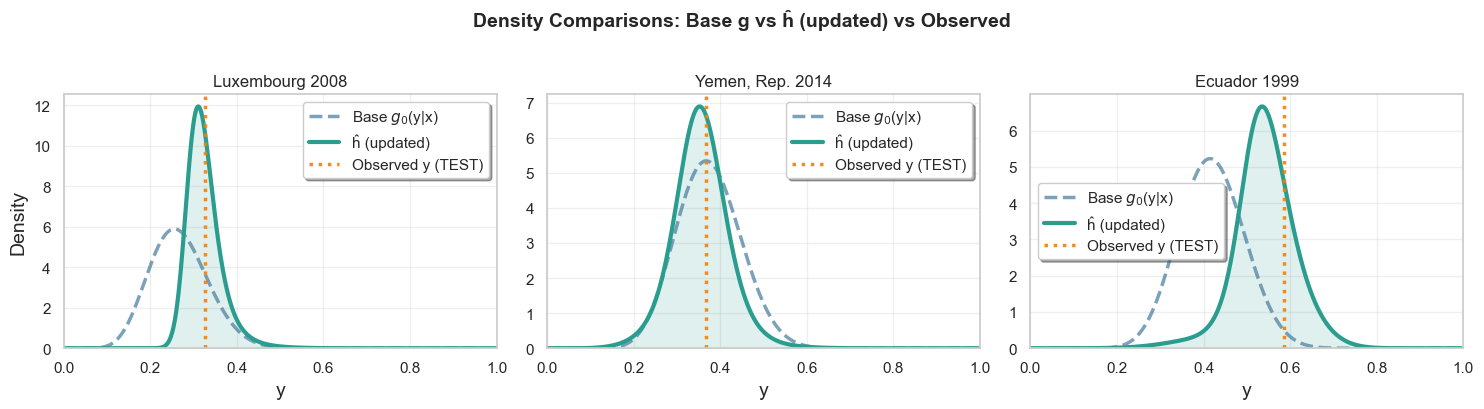

In [14]:
# Predictive density comparisons on the test set.
import seaborn as sns
sns.set(style="whitegrid")


# Densities at three representative test covariates.
idx_sorted = np.argsort(mu_hat_test)
sel_indices = [idx_sorted[int(0.01*len(idx_sorted))], idx_sorted[int((0.01+0.91)/2*len(idx_sorted))], idx_sorted[int(0.91*len(idx_sorted))]]

# Estimate GAM residual standard deviation (pure Gaussian; no Beta helpers)
sigma_gam = None
try:
    if 'mu_hat_gam' in df_train.columns:
        resid_gam = df_train['y_adj'].to_numpy() - df_train['mu_hat_gam'].to_numpy()
        sigma_gam = float(np.std(resid_gam, ddof=1))
    elif 'gam' in locals():
        # fallback: use model-reported scale if available
        sigma_gam = float(np.sqrt(gam.statistics_.get('scale', np.nan)))
except Exception:
    sigma_gam = None
if (sigma_gam is None) or (not np.isfinite(sigma_gam)) or (sigma_gam <= 0):
    # final fallback: use std of training targets
    sigma_gam = float(np.std(df_train['y_adj'].to_numpy(), ddof=1))
    if (not np.isfinite(sigma_gam)) or (sigma_gam <= 0):
        sigma_gam = 1e-3

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))

# Colors for the original base, GPDR, and observed response.
color_base = '#457B9D'    # blue for base g
color_updated = '#2A9D8F' # teal/green for updated ĥ
color_obs = '#F77F00'     # orange for observed

for j, (ax, ridx) in enumerate(zip(axes2, sel_indices)):
    x_star = X_gp_test.iloc[ridx].to_dict()
    y_true = df_test["y_adj"].to_numpy()[ridx]
    X_row = X_test.iloc[ridx]
    y_grid, g_vals, h_hat, exp_f, z_grid = model.predict_density(x_star_unscaled=x_star, X_row=X_row, df_row=df_test.iloc[ridx], y_min=1e-3, y_max=1-1e-3, M=1000)

    # Plot base and updated densities
    ax.plot(y_grid, g_vals, '--', color=color_base, linewidth=2.5, alpha=0.7, label=f'Base $g_0$(y|x)')
    ax.plot(y_grid, h_hat, '-', color=color_updated, linewidth=3.0, label='ĥ (updated)')
    ax.axvline(y_true, color=color_obs, linestyle=':', linewidth=2.5, alpha=0.9, label='Observed y (TEST)')

    # Subtle fill under the updated density curve
    ax.fill_between(y_grid, 0, h_hat, alpha=0.15, color=color_updated)

    # Title should reflect the conditional covariates (e.g., country and year),
    # not the observed y value which the densities are conditional on.
    row = df_test.iloc[ridx]
    country = row['country'] if 'country' in df_test.columns else ''
    year = row['year'] if 'year' in df_test.columns else ''
    try:
        year_str = str(int(year)) if (year is not None and not pd.isna(year)) else ''
    except Exception:
        year_str = str(year) if pd.notna(year) else ''
    title = f"{country} {year_str}".strip() or f"Obs y = {y_true:.3f}"
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('y', fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
    if j == 0:
        ax.set_ylabel('Density', fontsize=14)
    ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Density Comparisons: Base g vs ĥ (updated) vs Observed', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# Save figure
fig2.savefig("density_comparisons_base_updated_TEST.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Updated-model mean (MC)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Ensure we have MC-based updated means on TEST; compute if missing
if 'mu_hat_updated_mc' not in df_test.columns:
    N_eval = len(df_test)
    M_grid = 600
    S_samples = 1000
    rng = np.random.default_rng(123)
    
    def sample_from_density_grid(y_grid: np.ndarray, h_hat: np.ndarray, size: int, rng: np.random.Generator) -> np.ndarray:
        dy = np.diff(y_grid)
        wts = np.zeros_like(y_grid)
        wts[0] = dy[0] / 2.0
        wts[-1] = dy[-1] / 2.0
        wts[1:-1] = (dy[:-1] + dy[1:]) / 2.0
        prob = h_hat * wts
        prob_sum = prob.sum()
        if not np.isfinite(prob_sum) or prob_sum <= 0:
            prob = np.ones_like(prob) / prob.size
        else:
            prob = prob / prob_sum
        idx = rng.choice(y_grid.size, size=size, replace=True, p=prob)
        return y_grid[idx]
    
    updated_mean_mc = np.zeros(N_eval, dtype=float)
    for i in range(N_eval):
        x_star = X_gp_test.iloc[i].to_dict()
        X_row = X_test.iloc[i]
        y_grid, _, h_hat, _, _ = model.predict_density(x_star_unscaled=x_star, X_row=X_row, df_row=df_test.iloc[i], M=M_grid)
        ys = sample_from_density_grid(y_grid, h_hat, size=S_samples, rng=rng)
        updated_mean_mc[i] = float(ys.mean())
    df_test['mu_hat_updated_mc'] = updated_mean_mc


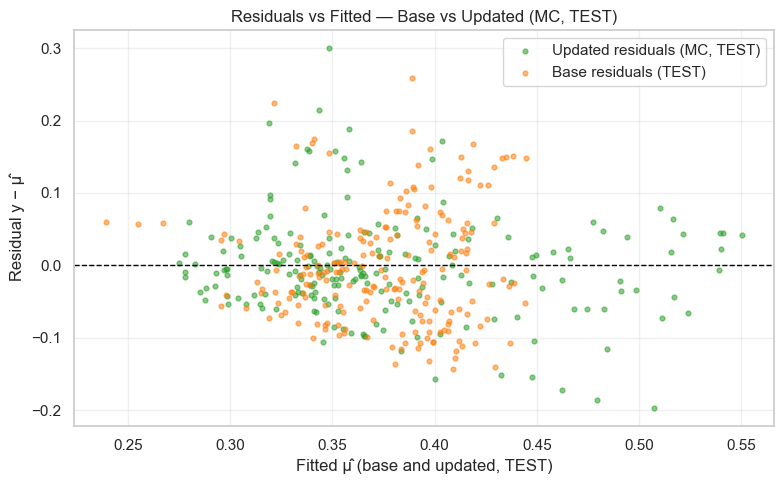

In [16]:
# Residuals overlay: Base vs Updated (MC point estimate) on TEST set
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Ensure base and updated TEST predictions exist
if 'mu_hat' not in df_test.columns:
    from scipy.special import expit
    mu_hat_test = expit(X_mat_test @ beta_hat)
    df_test['mu_hat'] = mu_hat_test

if 'mu_hat_updated_mc' not in df_test.columns:
    raise RuntimeError("Run the MC updated-mean TEST cell first to populate mu_hat_updated_mc in df_test.")

# Build arrays (TEST)
y_obs = df_test['y_adj'].to_numpy()
y_hat_base = df_test['mu_hat'].to_numpy()
y_hat_upd = df_test['mu_hat_updated_mc'].to_numpy()
resid_base = y_obs - y_hat_base
resid_upd = y_obs - y_hat_upd

# Single-axis overlay plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.scatter(y_hat_upd, resid_upd, s=12, alpha=0.55, color="#2ca02c", label="Updated residuals (MC, TEST)")
ax.scatter(y_hat_base, resid_base, s=12, alpha=0.55, color="#ff7f0e", label="Base residuals (TEST)")

ax.axhline(0.0, color="black", lw=1, linestyle="--")
ax.set_xlabel("Fitted μ̂ (base and updated, TEST)")
ax.set_ylabel("Residual y − μ̂")
ax.set_title("Residuals vs Fitted — Base vs Updated (MC, TEST)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
# Save figure
fig.savefig("residuals_overlay_base_updated_mc_TEST.pdf", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
# Mean test log score per observation: base Beta g vs updated GP ĥ.

import time

def format_elapsed_time(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    minutes, seconds = divmod(seconds, 60)
    if minutes < 60:
        return f"{int(minutes)}m {seconds:.1f}s"
    hours, minutes = divmod(minutes, 60)
    return f"{int(hours)}h {int(minutes)}m {seconds:.1f}s"

gini_logscore_start = time.perf_counter()

loglik_base = 0.0
loglik_updated = 0.0

for i in range(len(df_test)):
    y_star = float(df_test["y_adj"].iloc[i])
    mu_star = float(df_test["mu_hat"].iloc[i])
    
    # Base Beta log density at (x_i, y_i)
    a_star = mu_star * phi_hat
    b_star = (1.0 - mu_star) * phi_hat
    log_g = (
        gammaln(a_star + b_star)
        - gammaln(a_star)
        - gammaln(b_star)
        + (a_star - 1.0) * np.log(y_star)
        + (b_star - 1.0) * np.log(1.0 - y_star)
    )
    loglik_base += log_g
    
    # Updated density ĥ via model.predict_density and interpolation
    x_star = X_gp_test.iloc[i].to_dict()
    X_row = X_test.iloc[i]
    y_grid, g_grid, h_hat, _, _ = model.predict_density(
        x_star_unscaled=x_star,
        X_row=X_row,
        df_row=df_test.iloc[i],
        y_min=1e-3,
        y_max=1-1e-3,
        M=1000,
    )
    hhat_interp = np.interp(y_star, y_grid, h_hat)
    hhat_interp = max(hhat_interp, 1e-12)
    loglik_updated += np.log(hhat_interp)

n_test = len(df_test)
loglik_base /= n_test
loglik_updated /= n_test
print(f"Mean TEST log score (base Beta g):   {loglik_base:.4f}")
print(f"Mean TEST log score (updated GP ĥ): {loglik_updated:.4f}")

gini_logscore_time_seconds = time.perf_counter() - gini_logscore_start
print(f"GPDR log-score evaluation time: {format_elapsed_time(gini_logscore_time_seconds)}")


Mean TEST log score (base Beta g):   1.1577
Mean TEST log score (updated GP ĥ): 1.4447
GPDR log-score evaluation time: 0.88s


In [18]:
# Model Evaluation on TEST set: RMSE, Coverage, and Interval Length
import numpy as np
from scipy.stats import beta as beta_dist
import time

gini_metric_start = time.perf_counter()

# Number of samples for Monte Carlo estimation
n_samples = 3000
n_test = len(df_test)

# 1. Sample from base Beta regression model
def sample_from_base_model(X_row, n_samples):
    """Sample from base Beta(a, b) where a=mu*phi, b=(1-mu)*phi."""
    # X_row is from the already-transformed design matrix (with intercept)
    eta = beta_hat @ X_row.to_numpy()
    mu = expit(eta)
    a = mu * phi_hat
    b = (1.0 - mu) * phi_hat
    samples = beta_dist.rvs(a, b, size=n_samples, random_state=None)
    return samples

# 2. Sample from updated GP density model using inverse transform sampling
def sample_from_updated_model(x_star_unscaled, X_row, df_row, n_samples, M=1000):
    """Sample from updated density h(y|x) via inverse transform sampling."""
    y_grid, g_vals, h_hat, exp_f, z_grid = model.predict_density(
        x_star_unscaled=x_star_unscaled,
        X_row=X_row,
        df_row=df_row,
        y_min=1e-3,
        y_max=1-1e-3,
        M=M
    )
    
    # Compute weights for trapezoidal integration
    dy = np.diff(y_grid)
    wts = np.zeros_like(y_grid)
    wts[0] = dy[0] / 2.0
    wts[-1] = dy[-1] / 2.0
    wts[1:-1] = (dy[:-1] + dy[1:]) / 2.0
    
    # Probability mass for each grid point
    prob = h_hat * wts
    prob = prob / prob.sum()
    
    # Sample via inverse transform
    samples = np.random.choice(y_grid, size=n_samples, replace=True, p=prob)
    return samples

# Storage for results
base_samples_all = []
updated_samples_all = []

print("Generating samples for TEST set...")
for i in range(n_test):
    if (i + 1) % 50 == 0:
        print(f"  Processing {i+1}/{n_test}...")
    
    X_row = X_test.iloc[i]  # Full design row (with intercept)
    x_star = X_gp_test.iloc[i].to_dict()  # GP features (unscaled)
    df_row = df_test.iloc[i]
    
    # Sample from base model
    base_samp = sample_from_base_model(X_row, n_samples)
    base_samples_all.append(base_samp)
    
    # Sample from updated model
    updated_samp = sample_from_updated_model(x_star, X_row, df_row, n_samples)
    updated_samples_all.append(updated_samp)

base_samples_all = np.array(base_samples_all)  # (n_test, n_samples)
updated_samples_all = np.array(updated_samples_all)  # (n_test, n_samples)

# Section 1: RMSE
y_test_np = df_test["y_adj"].to_numpy()

# Point predictions: mean of samples
pred_base = base_samples_all.mean(axis=1)
pred_updated = updated_samples_all.mean(axis=1)

rmse_base = np.sqrt(np.mean((y_test_np - pred_base)**2))
rmse_updated = np.sqrt(np.mean((y_test_np - pred_updated)**2))

print("\n" + "="*60)
print("Section 1: Root Mean Squared Error (RMSE)")
print("="*60)
print(f"Base model RMSE:    {rmse_base:.6f}")
print(f"Updated model RMSE: {rmse_updated:.6f}")


# Section 2: 95% Credible Interval Coverage
# Compute equal-tailed 95% credible intervals
lower_base = np.percentile(base_samples_all, 2.5, axis=1)
upper_base = np.percentile(base_samples_all, 97.5, axis=1)

lower_updated = np.percentile(updated_samples_all, 2.5, axis=1)
upper_updated = np.percentile(updated_samples_all, 97.5, axis=1)

# Coverage: fraction of observations within the interval
coverage_base = np.mean((y_test_np >= lower_base) & (y_test_np <= upper_base))
coverage_updated = np.mean((y_test_np >= lower_updated) & (y_test_np <= upper_updated))

print("\n" + "="*60)
print("Section 2: 95% Credible Interval Coverage")
print("="*60)
print(f"Base model coverage:    {coverage_base:.4f}")
print(f"Updated model coverage: {coverage_updated:.4f}")


# Section 3: Average Credible Interval Length
avg_length_base = np.mean(upper_base - lower_base)
avg_length_updated = np.mean(upper_updated - lower_updated)

print("\n" + "="*60)
print("Section 3: Average 95% Credible Interval Length")
print("="*60)
print(f"Base model avg length:    {avg_length_base:.6f}")
print(f"Updated model avg length: {avg_length_updated:.6f}")

gini_metric_time_seconds = time.perf_counter() - gini_metric_start
gpdr_prediction_time_seconds = globals().get("gini_logscore_time_seconds", 0.0) + gini_metric_time_seconds
gpdr_prediction_time = format_elapsed_time(gpdr_prediction_time_seconds)
print(f"GPDR prediction/evaluation time: {gpdr_prediction_time}")


Generating samples for TEST set...
  Processing 50/210...
  Processing 100/210...
  Processing 150/210...
  Processing 200/210...

Section 1: Root Mean Squared Error (RMSE)
Base model RMSE:    0.077825
Updated model RMSE: 0.068983

Section 2: 95% Credible Interval Coverage
Base model coverage:    0.9381
Updated model coverage: 0.9333

Section 3: Average 95% Credible Interval Length
Base model avg length:    0.285313
Updated model avg length: 0.243939
GPDR prediction/evaluation time: 1.92s


In [19]:
# # ============================
# # Part 1: Generate Hyperparameter Candidates with Latin Hypercube Sampling
# # ============================

# import time
# import pickle
# from dataclasses import dataclass
# from scipy.stats import qmc
# from scipy.spatial.distance import pdist, squareform

# # Define interpretable parameter ranges (same as weather data example)
# # Kernel variance: σ range → log(σ²)
# sigma_range = (0.01, 1.0)
# log_sigma2_range = (math.log(sigma_range[0]**2), math.log(sigma_range[1]**2))

# # Lengthscale in x: lx range → log(lx²)
# lx_range = (0.01, 1.0)
# log_lx2_range = (math.log(lx_range[0]**2), math.log(lx_range[1]**2))

# # Lengthscale in z: lz range → log(lz²)
# lz_range = (0.01, 1.0)
# log_lz2_range = (math.log(lz_range[0]**2), math.log(lz_range[1]**2))

# # Learning weight: log-scale range
# log_beta_range = (math.log(0.01), math.log(2000))

# # Inducing points: FIXED at 200 (consistent with main training)
# m_induce_fixed = 200

# # Generate initial LHS candidates
# n_candidates = 100
# sampler = qmc.LatinHypercube(d=4)  # 4D: log_sigma2, log_lx2, log_lz2, beta
# lhs_samples = sampler.random(n=n_candidates)

# print(f"Generating {n_candidates} candidates using Latin Hypercube Sampling...")

# # LHS samples are already in [0, 1]^4
# candidates_normalized = lhs_samples.copy()

# print(f"✓ Created {len(candidates_normalized)} candidates from LHS\n")

# # Apply median heuristic to maximize minimal distance between candidates
# print("Optimizing candidate locations using median heuristic...")
# print("  Goal: Maximize the minimal pairwise distance between candidates")
# print("  Working in normalized [0, 1]^4 space for fair distance metric\n")

# max_iterations = 50
# learning_rate = 0.01

# for iteration in range(max_iterations):
#     # Compute pairwise distances in normalized space
#     dists = squareform(pdist(candidates_normalized, 'euclidean'))
    
#     # Set diagonal to infinity to avoid self-distances
#     np.fill_diagonal(dists, np.inf)
    
#     # Find minimum distance for each point
#     min_dists = np.min(dists, axis=1)
    
#     # Current objective: median of minimal distances
#     current_median_min_dist = np.median(min_dists)
    
#     # Find points with smallest minimal distances (need most improvement)
#     worst_points = np.argsort(min_dists)[:n_candidates // 10]  # Improve worst 10%
    
#     # Move worst points away from their nearest neighbors
#     for idx in worst_points:
#         nearest_neighbor_idx = np.argmin(dists[idx])
#         direction = candidates_normalized[idx] - candidates_normalized[nearest_neighbor_idx]
#         direction_norm = np.linalg.norm(direction)
        
#         if direction_norm > 1e-8:
#             # Move in direction away from nearest neighbor
#             candidates_normalized[idx] += learning_rate * direction / direction_norm
    
#     # Project back to [0, 1]^4 (clip to valid normalized range)
#     candidates_normalized = np.clip(candidates_normalized, 0.0, 1.0)

# # Final distance statistics
# dists_final = squareform(pdist(candidates_normalized, 'euclidean'))
# np.fill_diagonal(dists_final, np.inf)
# min_dists_final = np.min(dists_final, axis=1)

# print(f"\n✓ Optimization complete!")
# print(f"  Median minimal distance: {np.median(min_dists_final):.4f}")
# print(f"  Mean minimal distance:   {np.mean(min_dists_final):.4f}")
# print(f"  Min minimal distance:    {np.min(min_dists_final):.4f}\n")

# # Convert normalized [0, 1]^4 candidates to actual hyperparameter values
# print("Converting normalized candidates to hyperparameter space...")
# candidates = []

# for i in range(n_candidates):
#     # Extract normalized values
#     norm_log_sigma2 = candidates_normalized[i, 0]
#     norm_log_lx2 = candidates_normalized[i, 1]
#     norm_log_lz2 = candidates_normalized[i, 2]
#     norm_log_beta = candidates_normalized[i, 3]
    
#     # Scale to actual parameter ranges
#     log_sigma2 = log_sigma2_range[0] + norm_log_sigma2 * (log_sigma2_range[1] - log_sigma2_range[0])
#     log_lx2 = log_lx2_range[0] + norm_log_lx2 * (log_lx2_range[1] - log_lx2_range[0])
#     log_lz2 = log_lz2_range[0] + norm_log_lz2 * (log_lz2_range[1] - log_lz2_range[0])
#     log_beta = log_beta_range[0] + norm_log_beta * (log_beta_range[1] - log_beta_range[0])
#     beta = np.exp(log_beta)
    
#     candidates.append({
#         'log_sigma2': log_sigma2,
#         'log_lx2': log_lx2,
#         'log_lz2': log_lz2,
#         'beta': beta,
#         'm_induce': m_induce_fixed
#     })

# print(f"✓ Generated {len(candidates)} optimized hyperparameter candidates for cross-validation")


In [20]:
# # picle save the candidates for later use
# with open("hyperparameter_candidates_gini.pkl", "wb") as f:
#     pickle.dump(candidates, f)

In [21]:
# # pickle load candidates (if needed)
# with open("hyperparameter_candidates_gini.pkl", "rb") as f:
#     candidates = pickle.load(f)

In [22]:
# # ============================
# # Part 2: Cross-Validation Evaluation of Candidates
# # with Bayesian Optimization
# # ============================

# import time
# import math
# import pickle
# import numpy as np
# import torch
# import torch.optim as optim
# from dataclasses import dataclass
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
# from scipy.stats import norm

# BAD_LOG_SCORE = -1e12

# # ----------------------------
# # Initial candidate count
# # ----------------------------
# n_candidates = len(candidates)
# print(f"Testing with {n_candidates} initial candidates\n")

# # ----------------------------
# # CV kernel params helper
# # ----------------------------
# @dataclass
# class KernelParamsCV:
#     log_sigma2: float
#     log_lx2: float
#     log_lz2: float
    
#     def finalize(self, d_x):
#         """Create log_lx2 tensor for ARD with same value across x-dimensions."""
#         self.log_lx2_tensor = torch.log(
#             torch.full((d_x,), self.lx2, dtype=torch.get_default_dtype())
#         )
#         return self
    
#     @property
#     def sigma2(self):
#         return math.exp(self.log_sigma2)
    
#     @property
#     def lx2(self):
#         return math.exp(self.log_lx2)
    
#     @property
#     def lz2(self):
#         return math.exp(self.log_lz2)

# # ----------------------------
# # Density summary helper
# # ----------------------------
# def summarize_density_on_grid(y_grid, h_hat, y_obs, alpha=0.05):
#     """
#     Given a predictive density h_hat on y_grid, compute:
#       - log score at y_obs
#       - equal-tailed coverage indicator
#       - equal-tailed interval length
#     Return None if the density contains non-finite values.
#     """
#     y_grid = np.asarray(y_grid)
#     h_hat = np.asarray(h_hat)

#     if (not np.all(np.isfinite(y_grid))) or (not np.all(np.isfinite(h_hat))):
#         return None

#     dy = np.diff(y_grid)
#     wts = np.zeros_like(y_grid)
#     wts[0] = dy[0] / 2.0
#     wts[-1] = dy[-1] / 2.0
#     wts[1:-1] = (dy[:-1] + dy[1:]) / 2.0

#     prob = h_hat * wts
#     prob_sum = prob.sum()
#     if (not np.isfinite(prob_sum)) or (prob_sum <= 0):
#         prob = np.ones_like(prob) / prob.size
#     else:
#         prob = prob / prob_sum

#     cdf = np.cumsum(prob)
#     cdf = np.clip(cdf, 0.0, 1.0)
#     cdf[-1] = 1.0

#     hhat_interp = np.interp(y_obs, y_grid, h_hat)
#     if not np.isfinite(hhat_interp):
#         return None

#     log_score = np.log(max(hhat_interp, 1e-12))
#     lower = np.interp(alpha / 2.0, cdf, y_grid)
#     upper = np.interp(1.0 - alpha / 2.0, cdf, y_grid)

#     if not np.isfinite(log_score + lower + upper):
#         return None

#     covered = float((y_obs >= lower) and (y_obs <= upper))
#     interval_length = float(upper - lower)

#     return float(log_score), covered, interval_length

# # ----------------------------
# # Train one fold and evaluate on its validation subset
# # ----------------------------
# def train_and_evaluate_model_cv(log_sigma2, log_lx2, log_lz2, beta, 
#                                 x_train_fold, y_train_fold, x_val_fold, y_val_fold,
#                                 mu_base_train_fold, phi_base_scaled, device, val_cv_indices):
#     """Train model on training fold and evaluate on validation fold."""
#     kp = KernelParamsCV(
#         log_sigma2=log_sigma2,
#         log_lx2=log_lx2,
#         log_lz2=log_lz2
#     ).finalize(x_train_fold.size(1))
    
#     try:
#         global mu_base_train, phi_base

#         mu_base_train_backup = mu_base_train.copy()
#         phi_base_backup = phi_base

#         mu_base_train = mu_base_train_fold
#         phi_base = phi_base_scaled

#         model_cv = BetaGPMixtureDiag(
#             x_train_fold,
#             y_train_fold,
#             C=2,
#             m_induce=200,
#             beta=beta,
#             seed=2,
#             kp=KernelParams(
#                 log_sigma2=log_sigma2,
#                 log_lx2=kp.log_lx2_tensor,
#                 log_lz2=log_lz2
#             )
#         ).to(device)

#         mu_base_train = mu_base_train_backup
#         phi_base = phi_base_backup

#         optimizer_cv = optim.Adam(model_cv.parameters(), lr=0.5)

#         num_iterations = 2000
#         for iteration in range(num_iterations):
#             optimizer_cv.zero_grad()
#             F, info = model_cv.forward_objective()

#             if not torch.isfinite(F):
#                 return {
#                     "log_score": BAD_LOG_SCORE,
#                     "coverage95": 0.0,
#                     "avg_length95": np.inf,
#                     "failed": True,
#                     "fail_reason": "nonfinite_objective",
#                 }

#             F.backward()
#             optimizer_cv.step()

#         total_log_score = 0.0
#         coverage_hits = []
#         interval_lengths = []

#         for val_idx in val_cv_indices:
#             # val_idx indexes into the TRAIN dataset
#             X_row_idx = train_idx[val_idx]
#             X_row = X.iloc[X_row_idx]

#             x_star = {col: X_gp_train.iloc[val_idx][col] for col in X_gp_train.columns}
#             y_star = float(y_train[val_idx])

#             y_grid, g_vals, h_hat, exp_f_vals, z_grid = model_cv.predict_density(
#                 x_star_unscaled=x_star,
#                 X_row=X_row,
#                 y_min=1e-3,
#                 y_max=1-1e-3,
#                 M=1000
#             )

#             if (not np.all(np.isfinite(y_grid))) or (not np.all(np.isfinite(h_hat))) or (not np.all(np.isfinite(exp_f_vals))):
#                 return {
#                     "log_score": BAD_LOG_SCORE,
#                     "coverage95": 0.0,
#                     "avg_length95": np.inf,
#                     "failed": True,
#                     "fail_reason": "nonfinite_prediction_density",
#                 }

#             summary_i = summarize_density_on_grid(y_grid, h_hat, y_star, alpha=0.05)

#             if summary_i is None:
#                 return {
#                     "log_score": BAD_LOG_SCORE,
#                     "coverage95": 0.0,
#                     "avg_length95": np.inf,
#                     "failed": True,
#                     "fail_reason": "invalid_density_summary",
#                 }

#             log_score_i, covered_i, interval_len_i = summary_i
#             total_log_score += log_score_i
#             coverage_hits.append(covered_i)
#             interval_lengths.append(interval_len_i)

#         return {
#             "log_score": float(total_log_score),
#             "coverage95": float(np.mean(coverage_hits)),
#             "avg_length95": float(np.mean(interval_lengths)),
#             "failed": False,
#             "fail_reason": "",
#         }

#     except Exception as e:
#         print(f"\nError in CV: {e}")
#         import traceback
#         traceback.print_exc()
#         return {
#             "log_score": BAD_LOG_SCORE,
#             "coverage95": 0.0,
#             "avg_length95": np.inf,
#             "failed": True,
#             "fail_reason": str(e),
#         }

# # ----------------------------
# # 3-fold CV split on training data
# # ----------------------------
# n_train_cv = len(y_train)
# fold_size = n_train_cv // 3
# cv_seed = 42
# cv_indices = np.random.RandomState(cv_seed).permutation(n_train_cv)

# fold_indices = [
#     cv_indices[:fold_size],
#     cv_indices[fold_size:2 * fold_size],
#     cv_indices[2 * fold_size:]
# ]

# # ----------------------------
# # Evaluate one candidate by 3-fold CV
# # ----------------------------
# def evaluate_candidate(candidate):
#     fold_log_scores = []
#     fold_coverages95 = []
#     fold_lengths95 = []
#     fold_fail_reasons = []

#     for fold_id in range(3):
#         val_cv_indices = fold_indices[fold_id]
#         train_cv_indices = np.concatenate(
#             [fold_indices[i] for i in range(3) if i != fold_id]
#         )

#         x_train_fold = torch.from_numpy(X_gp_scaled[train_cv_indices]).to(torch.float64).to(device)
#         y_train_fold = torch.from_numpy(y_train[train_cv_indices]).to(torch.float64).to(device)
#         x_val_fold = torch.from_numpy(X_gp_scaled[val_cv_indices]).to(torch.float64).to(device)
#         y_val_fold = torch.from_numpy(y_train[val_cv_indices]).to(torch.float64).to(device)

#         mu_base_train_fold = mu_hat_train[train_cv_indices]

#         fold_result = train_and_evaluate_model_cv(
#             candidate["log_sigma2"],
#             candidate["log_lx2"],
#             candidate["log_lz2"],
#             candidate["beta"],
#             x_train_fold,
#             y_train_fold,
#             x_val_fold,
#             y_val_fold,
#             mu_base_train_fold,
#             phi_base,
#             device,
#             val_cv_indices
#         )

#         fold_log_scores.append(float(fold_result["log_score"]))
#         fold_coverages95.append(float(fold_result["coverage95"]))
#         fold_lengths95.append(float(fold_result["avg_length95"]))
#         fold_fail_reasons.append(fold_result.get("fail_reason", ""))

#         if fold_result.get("failed", False):
#             break

#     if any((not np.isfinite(s)) for s in fold_log_scores):
#         avg_log_score = BAD_LOG_SCORE
#     else:
#         avg_log_score = float(np.mean(fold_log_scores))

#     finite_coverages = [c for c in fold_coverages95 if np.isfinite(c)]
#     finite_lengths = [l for l in fold_lengths95 if np.isfinite(l)]

#     avg_coverage95 = float(np.mean(finite_coverages)) if len(finite_coverages) > 0 else 0.0
#     avg_length95 = float(np.mean(finite_lengths)) if len(finite_lengths) > 0 else np.inf

#     if not np.isfinite(avg_log_score):
#         avg_log_score = BAD_LOG_SCORE

#     return {
#         "log_sigma2": candidate["log_sigma2"],
#         "log_lx2": candidate["log_lx2"],
#         "log_lz2": candidate["log_lz2"],
#         "beta": candidate["beta"],
#         "m_induce": candidate["m_induce"],
#         "avg_log_score": float(avg_log_score),
#         "avg_coverage95": float(avg_coverage95),
#         "avg_length95": float(avg_length95) if np.isfinite(avg_length95) else np.inf,
#         "selection_score": float(avg_log_score),
#         "fold_log_scores": fold_log_scores,
#         "fold_coverages95": fold_coverages95,
#         "fold_lengths95": fold_lengths95,
#         "fold_fail_reasons": fold_fail_reasons,
#     }

# # ----------------------------
# # Bayesian optimization helper functions
# # ----------------------------
# sigma_range = (math.log(0.01**2), math.log(1.0**2))
# lx_range = (math.log(0.01**2), math.log(1.0**2))
# lz_range = (math.log(0.01**2), math.log(1.0**2))
# logbeta_range = (math.log(0.01), math.log(2000.0))

# def candidate_to_x(candidate):
#     return np.array([
#         (candidate["log_sigma2"] - sigma_range[0]) / (sigma_range[1] - sigma_range[0]),
#         (candidate["log_lx2"] - lx_range[0]) / (lx_range[1] - lx_range[0]),
#         (candidate["log_lz2"] - lz_range[0]) / (lz_range[1] - lz_range[0]),
#         (math.log(candidate["beta"]) - logbeta_range[0]) / (logbeta_range[1] - logbeta_range[0]),
#     ], dtype=float)

# def x_to_candidate(x):
#     x = np.clip(x, 0.0, 1.0)
#     return {
#         "log_sigma2": sigma_range[0] + x[0] * (sigma_range[1] - sigma_range[0]),
#         "log_lx2": lx_range[0] + x[1] * (lx_range[1] - lx_range[0]),
#         "log_lz2": lz_range[0] + x[2] * (lz_range[1] - lz_range[0]),
#         "beta": float(np.exp(logbeta_range[0] + x[3] * (logbeta_range[1] - logbeta_range[0]))),
#         "m_induce": 200,
#     }

# def expected_improvement(X, gp, y_best, xi=0.01):
#     mu, std = gp.predict(X, return_std=True)
#     std = np.maximum(std, 1e-12)

#     improvement = mu - y_best - xi
#     Z = improvement / std
#     ei = improvement * norm.cdf(Z) + std * norm.pdf(Z)
#     ei[std <= 1e-12] = 0.0
#     return ei

# # ----------------------------
# # Evaluate initial candidates
# # ----------------------------
# all_results = []
# results_file = "cv_results_gini.pkl"
# start_time = time.time()

# print("\n" + "=" * 80)
# print(f"Starting 3-fold CV on {n_train_cv} training samples")
# print(f"Initial candidates: {n_candidates}")
# print(f"Fold sizes: {[len(fold) for fold in fold_indices]}")
# print(f"Results will be saved to: {results_file}")
# print("=" * 80 + "\n")

# for idx, candidate in enumerate(candidates):
#     result = evaluate_candidate(candidate)

#     all_results.append(result)

#     with open(results_file, "wb") as f:
#         pickle.dump(all_results, f)

#     elapsed = time.time() - start_time
#     est_total = elapsed * n_candidates / (idx + 1)
#     est_remaining = est_total - elapsed

#     fail_msg = ""
#     if result["avg_log_score"] <= BAD_LOG_SCORE / 10:
#         fail_msg = f" | penalized: {result.get('fold_fail_reasons', [''])[0]}"

#     print(
#         f"Initial {idx+1:3d}/{n_candidates} | "
#         f"log_score={result['avg_log_score']:.2f} | "
#         f"coverage95={result['avg_coverage95']:.4f} | "
#         f"length95={result['avg_length95']:.4f} | "
#         f"elapsed={elapsed/60:.1f}m | remain~{est_remaining/60:.1f}m"
#         f"{fail_msg}"
#     )

# print("\nFinished initial candidate evaluation.")
# print(f"Total evaluations: {len(all_results)}")

# # ----------------------------
# # Bayesian optimization stage
# # ----------------------------
# n_bo_iters = 100
# bo_pool_size = 2000
# bo_xi = 0.01

# print("\n" + "=" * 80)
# print(f"Starting Bayesian optimization for {n_bo_iters} additional iterations")
# print("BO target: avg_log_score")
# print("=" * 80 + "\n")

# for bo_iter in range(n_bo_iters):
#     # Build GP surrogate from current results
#     X_obs = np.array([candidate_to_x(r) for r in all_results], dtype=float)
#     y_obs = np.array([r["avg_log_score"] for r in all_results], dtype=float)

#     gp_kernel = (
#         ConstantKernel(1.0, (1e-3, 1e3))
#         * Matern(length_scale=np.ones(4), length_scale_bounds=(1e-2, 1e2), nu=2.5)
#         + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
#     )

#     gp = GaussianProcessRegressor(
#         kernel=gp_kernel,
#         alpha=1e-8,
#         normalize_y=True,
#         n_restarts_optimizer=3,
#         random_state=123 + bo_iter,
#     )

#     gp.fit(X_obs, y_obs)

#     # Random candidate pool for acquisition
#     rng_bo = np.random.default_rng(1000 + bo_iter)
#     X_pool = rng_bo.uniform(0.0, 1.0, size=(bo_pool_size, 4))

#     # Avoid re-querying exact existing points
#     existing_set = {tuple(np.round(x, 10)) for x in X_obs}
#     keep_mask = np.array([tuple(np.round(x, 10)) not in existing_set for x in X_pool])
#     X_pool = X_pool[keep_mask]

#     if X_pool.shape[0] == 0:
#         print(f"BO iter {bo_iter+1:3d}/{n_bo_iters} | candidate pool empty, stopping early.")
#         break

#     current_best = np.max(y_obs)
#     ei = expected_improvement(X_pool, gp, current_best, xi=bo_xi)
#     best_pool_idx = int(np.argmax(ei))
#     x_new = X_pool[best_pool_idx]
#     candidate_new = x_to_candidate(x_new)

#     result_new = evaluate_candidate(candidate_new)
#     all_results.append(result_new)

#     with open(results_file, "wb") as f:
#         pickle.dump(all_results, f)

#     elapsed = time.time() - start_time
#     fail_msg = ""
#     if result_new["avg_log_score"] <= BAD_LOG_SCORE / 10:
#         fail_msg = f" | penalized: {result_new.get('fold_fail_reasons', [''])[0]}"

#     print(
#         f"BO {bo_iter+1:3d}/{n_bo_iters} | "
#         f"log_score={result_new['avg_log_score']:.2f} | "
#         f"coverage95={result_new['avg_coverage95']:.4f} | "
#         f"length95={result_new['avg_length95']:.4f} | "
#         f"elapsed={elapsed/60:.1f}m"
#         f"{fail_msg}"
#     )

# # ----------------------------
# # Final ranking
# # ----------------------------
# all_results_sorted = sorted(all_results, key=lambda d: d["avg_log_score"], reverse=True)
# best = all_results_sorted[0]

# print("\n" + "=" * 80)
# print("Cross-validation + BO complete.")
# print(f"Total evaluations: {len(all_results)}")
# print("\nBest candidate by avg_log_score:")
# print(best)
# print(f"\nBest avg_log_score   : {best['avg_log_score']:.6f}")
# print(f"Best avg_coverage95  : {best['avg_coverage95']:.6f}")
# print(f"Best avg_length95    : {best['avg_length95']:.6f}")

# # Save final results once more
# with open(results_file, "wb") as f:
#     pickle.dump(all_results, f)

In [23]:
# # Find best hyperparameters and visualize results
# if len(all_results) > 0:
#     all_results_sorted = sorted(all_results, key=lambda x: x['avg_log_score'], reverse=True)

#     best = all_results_sorted[0]
    
#     print("\n" + "="*70)
#     print("BEST HYPERPARAMETERS (3-Fold Cross-Validation)")
#     print("="*70)
#     print(f"  σ = {np.sqrt(np.exp(best['log_sigma2'])):.4f}")
#     print(f"  lx = {np.sqrt(np.exp(best['log_lx2'])):.4f}")
#     print(f"  lz = {np.sqrt(np.exp(best['log_lz2'])):.4f}")
#     print(f"  β = {best['beta']:.2f}")
#     print(f"  m = {best['m_induce']}")
#     print(f"\nAverage validation log-score: {best['avg_log_score']:.4f}")
#     print(f"Average coverage95: {best['avg_coverage95']:.4f}")
#     print("="*70)
    
#     # Display top 5 candidates
#     print("\n" + "="*70)
#     print("TOP 5 HYPERPARAMETER CANDIDATES")
#     print("="*70)
#     for rank, result in enumerate(all_results_sorted[:5], 1):
#         print(f"\nRank {rank}:")
#         print(f"  σ = {np.sqrt(np.exp(result['log_sigma2'])):.4f}, "
#               f"lx = {np.sqrt(np.exp(result['log_lx2'])):.4f}, "
#               f"lz = {np.sqrt(np.exp(result['log_lz2'])):.4f}, "
#               f"β = {result['beta']:.2f}, "
#               f"m = {result['m_induce']}")
#         print(f"  Avg log-score: {result['avg_log_score']:.4f}")
#         print(f"  Average coverage95: {result['avg_coverage95']:.4f}")
#     print("="*70)
    
#     # Save results
#     with open("hyperparameter_search_cv_results_withbo_gini.pkl", "wb") as f:
#         pickle.dump({'best': best, 'all_results': all_results}, f)
#     print("\nResults saved to hyperparameter_search_cv_results_withbo_gini.pkl")
# else:
#     print("\nNo successful evaluations!")


In [24]:
# # load results
# with open("hyperparameter_search_cv_results_gini.pkl", "rb") as f:
#     cv_results = pickle.load(f)
#     best = cv_results['best']
#     all_results = cv_results['all_results']

### Quantile Residual Diagnostics

These panels compare the original Beta base `g_0` and GPDR. The x-axis is each model's fitted mean Gini proportion; the y-axis is `Phi^{-1}(F(y_i | x_i))`, using that model's fitted CDF `F` and the standard Normal CDF `Phi`. Roughly standard-Normal residuals without a systematic trend or changing spread support conditional calibration.


Gini quantile residual diagnostics
subset_size_used: 210

base_g0
    mean: -0.021356
     std: 1.042448
     q05: -1.465164
  median: -0.095977
     q95: 1.960676

gpdr
    mean: 0.018654
     std: 1.040047
     q05: -1.550824
  median: -0.104526
     q95: 2.008357


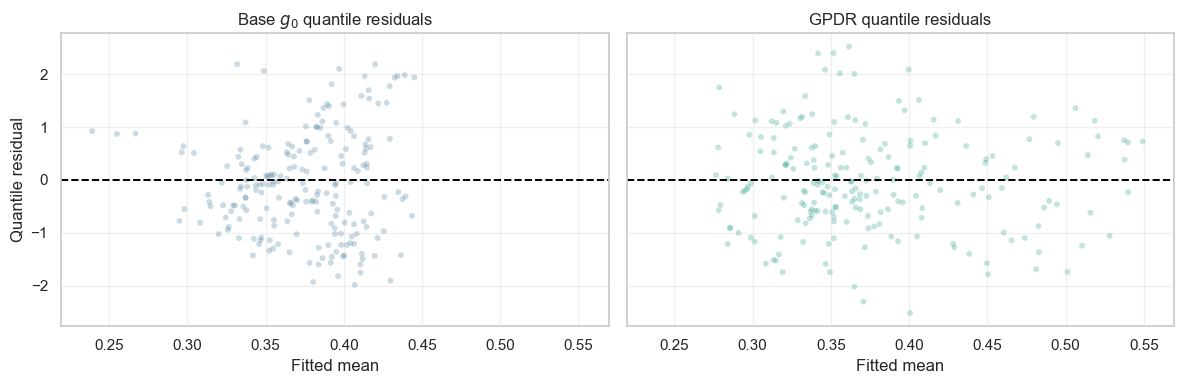

In [25]:
# QUANTILE_RESIDUAL_DIAGNOSTIC_GINI
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


def quantile_residual_diagnostic_gini(model, X_gp_eval, X_eval, df_eval, y_col="y_adj", y_min=1e-3, y_max=1-1e-3, M=1000, eps=1e-10, subset_size=None, seed=123):
    """Compute quantile residuals for GPDR and the Beta base model g_0, optionally on a reproducible subset."""
    gpdr_pit = []
    gpdr_mean = []
    base_pit = []
    base_mean = []

    n_total = len(df_eval)
    if subset_size is not None and subset_size < n_total:
        rng = np.random.default_rng(seed)
        use_idx = np.sort(rng.choice(n_total, size=subset_size, replace=False))
    else:
        use_idx = np.arange(n_total)

    X_gp_eval_use = X_gp_eval.iloc[use_idx].reset_index(drop=True)
    X_eval_use = X_eval.iloc[use_idx].reset_index(drop=True)
    df_eval_use = df_eval.iloc[use_idx].reset_index(drop=True)

    for i in range(len(df_eval_use)):
        y_obs = float(df_eval_use[y_col].iloc[i])
        x_star = X_gp_eval_use.iloc[i].to_dict()
        X_row = X_eval_use.iloc[i]

        y_grid, _, h_hat, _, _ = model.predict_density(
            x_star_unscaled=x_star,
            X_row=X_row,
            df_row=df_eval_use.iloc[i],
            y_min=y_min,
            y_max=y_max,
            M=M,
        )

        dy = np.diff(y_grid)
        wts = np.zeros_like(y_grid)
        wts[0] = dy[0] / 2.0
        wts[-1] = dy[-1] / 2.0
        wts[1:-1] = (dy[:-1] + dy[1:]) / 2.0

        prob = h_hat * wts
        prob_sum = prob.sum()
        if (not np.isfinite(prob_sum)) or (prob_sum <= 0):
            prob = np.ones_like(prob) / prob.size
        else:
            prob = prob / prob_sum

        cdf = np.cumsum(prob)
        cdf = np.clip(cdf, 0.0, 1.0)
        pit_i = np.interp(y_obs, y_grid, cdf)
        gpdr_pit.append(pit_i)
        gpdr_mean.append(float(np.sum(y_grid * prob)))

        mu_base_i = float(df_eval_use["mu_hat"].iloc[i])
        a_base_i = mu_base_i * phi_hat
        b_base_i = (1.0 - mu_base_i) * phi_hat
        base_mean.append(mu_base_i)
        base_pit.append(beta_dist.cdf(y_obs, a_base_i, b_base_i))

    gpdr_pit = np.clip(np.asarray(gpdr_pit), eps, 1.0 - eps)
    base_pit = np.clip(np.asarray(base_pit), eps, 1.0 - eps)
    gpdr_mean = np.asarray(gpdr_mean)
    base_mean = np.asarray(base_mean)

    gpdr_resid = norm.ppf(gpdr_pit)
    base_resid = norm.ppf(base_pit)

    return {
        "gpdr": {
            "pit": gpdr_pit,
            "quantile_residual": gpdr_resid,
            "fitted_mean": gpdr_mean,
            "summary": {
                "mean": float(np.mean(gpdr_resid)),
                "std": float(np.std(gpdr_resid, ddof=1)),
                "q05": float(np.quantile(gpdr_resid, 0.05)),
                "median": float(np.quantile(gpdr_resid, 0.50)),
                "q95": float(np.quantile(gpdr_resid, 0.95)),
            },
        },
        "base_g0": {
            "pit": base_pit,
            "quantile_residual": base_resid,
            "fitted_mean": base_mean,
            "summary": {
                "mean": float(np.mean(base_resid)),
                "std": float(np.std(base_resid, ddof=1)),
                "q05": float(np.quantile(base_resid, 0.05)),
                "median": float(np.quantile(base_resid, 0.50)),
                "q95": float(np.quantile(base_resid, 0.95)),
            },
        },
        "subset_idx": use_idx,
    }


gini_qr_diag = quantile_residual_diagnostic_gini(
    model,
    X_gp_test,  # Use only TEST set for GP features to match df_test
    X_test,  # Use only TEST set for X_eval to match df_test
    df_test,  # Use only TEST set for df_eval to match y_col and mu_hat
    y_col="y_adj",
    y_min=1e-3,
    y_max=1-1e-3,
    M=1000,
    subset_size=210,
    seed=123,
)

print("Gini quantile residual diagnostics")
print("=" * 60)
print(f"subset_size_used: {len(gini_qr_diag['subset_idx'])}")
for model_name in ["base_g0", "gpdr"]:
    payload = gini_qr_diag[model_name]
    print()
    print(model_name)
    for key, value in payload["summary"].items():
        print(f"  {key:>6s}: {value:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_specs = [
    ("base_g0", axes[0], r"Base $g_0$ quantile residuals", "#457B9D"),
    ("gpdr", axes[1], "GPDR quantile residuals", "#2A9D8F"),
]

all_resid = np.concatenate([
    gini_qr_diag["base_g0"]["quantile_residual"],
    gini_qr_diag["gpdr"]["quantile_residual"],
])
y_lo = float(np.quantile(all_resid, 0.001))
y_hi = float(np.quantile(all_resid, 0.999))
rng = np.random.default_rng(123)

x_min_common = float(min(gini_qr_diag["base_g0"]["fitted_mean"].min(), gini_qr_diag["gpdr"]["fitted_mean"].min())) - 0.02
x_max_common = float(max(gini_qr_diag["base_g0"]["fitted_mean"].max(), gini_qr_diag["gpdr"]["fitted_mean"].max())) + 0.02 

for key, ax, title, color in plot_specs:
    fitted_mean = np.asarray(gini_qr_diag[key]["fitted_mean"])
    residual = np.asarray(gini_qr_diag[key]["quantile_residual"])

    keep_mask = np.ones(residual.shape[0], dtype=bool)
    if residual.shape[0] > 5: # Omit the five largest absolute residuals outliers from this panel only.
        drop_idx = np.argsort(np.abs(residual))[-5:]
        keep_mask[drop_idx] = False

    fitted_mean_plot = fitted_mean[keep_mask]
    residual_plot = residual[keep_mask]

    jitter_scale = 0.004 * max(fitted_mean.max() - fitted_mean.min(), 1e-6)
    fitted_mean_jitter = fitted_mean_plot + rng.normal(0.0, jitter_scale, size=fitted_mean_plot.shape[0])

    ax.scatter(fitted_mean_jitter, residual_plot, s=18, alpha=0.28, color=color, edgecolors="none")
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.4)
    ax.set_title(title)
    ax.set_xlabel("Fitted mean")
    ax.set_xlim(x_min_common, x_max_common)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Quantile residual")
plt.tight_layout()
plt.savefig("gini_quantile_residuals_vs_fitted_mean.pdf", dpi=300, bbox_inches="tight")
plt.show()


### Benchmark Specifications

All benchmarks reuse the GPDR training and test observations and the adjusted Gini proportion `y_adj`. The predictors are `log_gdppc`, `urban`, `unemp`, `trade`, and `year`. Fitting uses package defaults except for the explicit settings below; response families and formulas specify the competing models.

- **GAMLSS:** Beta family, with `y ~ pb(log_gdppc) + pb(urban) + pb(unemp) + pb(trade) + pb(year)` and the same additive formula for `sigma`. The penalized B-spline terms allow both the mean and the Beta scale parameter to vary with the predictors.
- **TRAM:** `BoxCox(y ~ B, order=6)`, where `B` denotes the additive collection of `bs` columns for those five predictors. Cubic degree and basis size use the `bs` defaults; boundary knots span the observed train/test covariate ranges.
- **QRF:** all five predictors enter `quantile_forest` with default forest tuning settings; seed and thread count are fixed.
- **DDPstar:** `y ~ f(log_gdppc) + f(urban) + f(unemp) + f(trade) + f(year)`, using default P-spline terms and priors. The current MCMC settings are 1,000 burn-in and 1,000 retained draws (`nskip=1`), rather than the default 2,000/8,000, to reduce runtime.


In [165]:
# Prepare benchmark data from the exact same GPDR train/test split.
# Do not create a new train/test split here.

import pandas as pd
import numpy as np

benchmark_covariates_gini = ["log_gdppc", "urban", "unemp", "trade", "year"]

benchmark_train_gini = df_train[benchmark_covariates_gini].copy()
benchmark_train_gini["y"] = np.clip(df_train["y_adj"].to_numpy(dtype=float), 1e-6, 1.0 - 1e-6)

benchmark_test_gini = df_test[benchmark_covariates_gini].copy()
benchmark_test_gini["y"] = np.clip(df_test["y_adj"].to_numpy(dtype=float), 1e-6, 1.0 - 1e-6)

if "sel_indices" in globals():
    density_example_indices_gini = np.asarray(sel_indices, dtype=int)
else:
    idx_sorted_benchmark = np.argsort(df_test["mu_hat"].to_numpy())
    density_example_indices_gini = np.asarray([
        idx_sorted_benchmark[int(0.01 * len(idx_sorted_benchmark))],
        idx_sorted_benchmark[int((0.01 + 0.91) / 2 * len(idx_sorted_benchmark))],
        idx_sorted_benchmark[int(0.91 * len(idx_sorted_benchmark))],
    ], dtype=int)

print("Benchmark train shape:", benchmark_train_gini.shape)
print("Benchmark test shape: ", benchmark_test_gini.shape)
print("Density example test indices:", density_example_indices_gini.tolist())



Benchmark train shape: (1883, 6)
Benchmark test shape:  (210, 6)
Density example test indices: [50, 200, 182]


In [166]:
# Load R bridge for benchmark models.
%load_ext rpy2.ipython



The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


### GAMLSS Benchmark

In [167]:
%%R -i benchmark_train_gini -i benchmark_test_gini -i density_example_indices_gini -o gamlss_gini_metrics -o gamlss_gini_density_examples

suppressPackageStartupMessages({
    library(gamlss)
    library(gamlss.dist)
})

format_prediction_time <- function(seconds) {
    seconds <- as.numeric(seconds)
    if (seconds < 60) return(sprintf("%.2fs", seconds))
    minutes <- floor(seconds / 60)
    seconds <- seconds - 60 * minutes
    if (minutes < 60) return(sprintf("%dm %.1fs", minutes, seconds))
    hours <- floor(minutes / 60)
    minutes <- minutes - 60 * hours
    sprintf("%dh %dm %.1fs", hours, minutes, seconds)
}

train_df <- as.data.frame(benchmark_train_gini)
test_df <- as.data.frame(benchmark_test_gini)
train_df$y <- pmin(pmax(train_df$y, 1e-6), 1 - 1e-6)
test_df$y <- pmin(pmax(test_df$y, 1e-6), 1 - 1e-6)

fit_gamlss_gini <- gamlss(
    y ~ pb(log_gdppc) + pb(urban) + pb(unemp) + pb(trade) + pb(year),
    sigma.formula = ~ pb(log_gdppc) + pb(urban) + pb(unemp) + pb(trade) + pb(year),
    family = BE(),
    data = train_df,
    trace = FALSE
)

prediction_start <- Sys.time()

mu_t <- predict(fit_gamlss_gini, what = "mu", newdata = test_df, type = "response")
sigma_t <- predict(fit_gamlss_gini, what = "sigma", newdata = test_df, type = "response")
mu_t <- pmin(pmax(mu_t, 1e-6), 1 - 1e-6)
sigma_t <- pmax(sigma_t, 1e-8)
yt <- test_df$y

log_score <- mean(dBE(yt, mu = mu_t, sigma = sigma_t, log = TRUE))
rmse_mean <- sqrt(mean((yt - mu_t)^2))
lower <- qBE(0.025, mu = mu_t, sigma = sigma_t)
upper <- qBE(0.975, mu = mu_t, sigma = sigma_t)
coverage95 <- mean(yt >= lower & yt <= upper, na.rm = TRUE)
avg_width95 <- mean(upper - lower, na.rm = TRUE)
prediction_time <- format_prediction_time(difftime(Sys.time(), prediction_start, units = "secs"))

gamlss_gini_metrics <- data.frame(
    method = "GAMLSS Beta",
    log_score = log_score,
    rmse_mean = rmse_mean,
    coverage95 = coverage95,
    avg_width95 = avg_width95,
    prediction_time = prediction_time
)

# Predictive densities at the same three representative TEST cases used in the GPDR plot.
y_grid <- seq(1e-3, 1 - 1e-3, length.out = 600)
gamlss_gini_density_examples <- data.frame()
for (j in seq_along(density_example_indices_gini)) {
    ii <- as.integer(density_example_indices_gini[j]) + 1L
    dens <- dBE(y_grid, mu = mu_t[ii], sigma = sigma_t[ii])
    gamlss_gini_density_examples <- rbind(
        gamlss_gini_density_examples,
        data.frame(example = j, test_index = ii - 1L, y_grid = y_grid, density = dens, observed_y = yt[ii])
    )
}

print(gamlss_gini_metrics)



       method log_score  rmse_mean coverage95 avg_width95 prediction_time
1 GAMLSS Beta   310.943 0.07193753  0.9285714    0.248916           0.07s


此外: 警告信息:
1: In RS() : Algorithm RS has not yet converged
2: In predict.gamlss(fit_gamlss_gini, what = "sigma", newdata = test_df,  :
  There is a discrepancy  between the original and the re-fit 
 used to achieve 'safe' predictions 
 


### TRAM Benchmark

In [168]:
%%R -i benchmark_train_gini -i benchmark_test_gini -i density_example_indices_gini -o tram_gini_metrics -o tram_gini_density_examples

suppressPackageStartupMessages({
    library(tram)
    library(splines)
})

format_prediction_time <- function(seconds) {
    seconds <- as.numeric(seconds)
    if (seconds < 60) return(sprintf("%.2fs", seconds))
    minutes <- floor(seconds / 60)
    seconds <- seconds - 60 * minutes
    if (minutes < 60) return(sprintf("%dm %.1fs", minutes, seconds))
    hours <- floor(minutes / 60)
    minutes <- minutes - 60 * hours
    sprintf("%dh %dm %.1fs", hours, minutes, seconds)
}

train_df <- as.data.frame(benchmark_train_gini)
test_df <- as.data.frame(benchmark_test_gini)
train_df$y <- pmin(pmax(train_df$y, 1e-6), 1 - 1e-6)
test_df$y <- pmin(pmax(test_df$y, 1e-6), 1 - 1e-6)

tram_vars <- c("log_gdppc", "urban", "unemp", "trade", "year")

define_tram_basis <- function(train_df, test_df, vars) {
    train_basis <- data.frame(y = train_df$y)
    test_basis <- data.frame(y = test_df$y)

    for (v in vars) {
        boundary <- range(c(train_df[[v]], test_df[[v]]), na.rm = TRUE)
        if (!is.finite(boundary[1]) || !is.finite(boundary[2]) || boundary[1] == boundary[2]) {
            train_basis[[v]] <- train_df[[v]]
            test_basis[[v]] <- test_df[[v]]
            next
        }
        b_train <- bs(train_df[[v]], Boundary.knots = boundary, intercept = FALSE)
        b_test <- predict(b_train, test_df[[v]])
        for (j in seq_len(ncol(b_train))) {
            nm <- paste0("b_", v, "_", j)
            train_basis[[nm]] <- b_train[, j]
            test_basis[[nm]] <- b_test[, j]
        }
    }

    terms <- setdiff(names(train_basis), "y")
    list(train = train_basis, test = test_basis, terms = terms)
}

tram_basis <- define_tram_basis(train_df, test_df, tram_vars)
tram_formula <- as.formula(paste("y ~", paste(tram_basis$terms, collapse = " + ")))

fit_tram_gini <- BoxCox(
    tram_formula,
    data = tram_basis$train,
    order = 6
)

xt <- tram_basis$test[, tram_basis$terms, drop = FALSE]
yt <- tram_basis$test$y

tram_log_score <- function(fit, xt, yt, chunk_size = 250L, eps = 1e-12) {
    n <- length(yt)
    out <- numeric(n)
    for (s in seq.int(1L, n, by = chunk_size)) {
        e <- min(s + chunk_size - 1L, n)
        idx <- s:e
        dens_mat <- predict(fit, newdata = xt[idx, , drop = FALSE], q = yt[idx], type = "density")
        dens_mat <- as.matrix(dens_mat)
        if (nrow(dens_mat) == length(idx) && ncol(dens_mat) == length(idx)) {
            dens_obs <- diag(dens_mat)
        } else {
            dens_obs <- as.numeric(dens_mat)
            if (length(dens_obs) != length(idx)) {
                stop(sprintf("Unexpected TRAM density-at-observed shape: %d x %d", nrow(dens_mat), ncol(dens_mat)))
            }
        }
        out[idx] <- log(pmax(dens_obs, eps))
    }
    mean(out)
}

prediction_start <- Sys.time()

log_score <- tram_log_score(fit_tram_gini, xt, yt)

q_grid <- seq(1e-3, 1 - 1e-3, length.out = 700)
dy <- q_grid[2] - q_grid[1]
dens_grid <- predict(fit_tram_gini, newdata = xt, q = q_grid, type = "density")
dens_grid <- as.matrix(dens_grid)
if (nrow(dens_grid) == length(yt) && ncol(dens_grid) == length(q_grid)) {
    dens_grid <- t(dens_grid)
}
if (!(nrow(dens_grid) == length(q_grid) && ncol(dens_grid) == length(yt))) {
    stop(sprintf("Unexpected TRAM density grid shape: %d x %d", nrow(dens_grid), ncol(dens_grid)))
}

mass <- pmax(colSums(dens_grid) * dy, 1e-12)
est_mean <- (colSums(dens_grid * q_grid) * dy) / mass
rmse_mean <- sqrt(mean((yt - est_mean)^2))

weighted_quantile_from_grid <- function(dens_col, prob) {
    dens_col <- ifelse(is.finite(dens_col), dens_col, 0)
    dens_col <- pmax(dens_col, 0)
    cdf <- cumsum(dens_col) * dy
    total <- max(cdf[length(cdf)], 1e-12)
    cdf <- cdf / total
    keep <- is.finite(cdf) & !duplicated(cdf)
    if (sum(keep) < 2L) {
        return(q_grid[which.max(dens_col)])
    }
    approx(cdf[keep], q_grid[keep], xout = prob, rule = 2, ties = "ordered")$y
}

lower <- apply(dens_grid, 2, weighted_quantile_from_grid, prob = 0.025)
upper <- apply(dens_grid, 2, weighted_quantile_from_grid, prob = 0.975)
coverage95 <- mean(yt >= lower & yt <= upper, na.rm = TRUE)
avg_width95 <- mean(upper - lower, na.rm = TRUE)
prediction_time <- format_prediction_time(difftime(Sys.time(), prediction_start, units = "secs"))

tram_gini_metrics <- data.frame(
    method = "TRAM BoxCox",
    log_score = log_score,
    rmse_mean = rmse_mean,
    coverage95 = coverage95,
    avg_width95 = avg_width95,
    prediction_time = prediction_time
)

tram_gini_density_examples <- data.frame()
for (j in seq_along(density_example_indices_gini)) {
    ii <- as.integer(density_example_indices_gini[j]) + 1L
    dens <- as.numeric(predict(
        fit_tram_gini,
        newdata = xt[ii, , drop = FALSE],
        q = q_grid,
        type = "density"
    ))
    tram_gini_density_examples <- rbind(
        tram_gini_density_examples,
        data.frame(example = j, test_index = ii - 1L, y_grid = q_grid, density = dens, observed_y = yt[ii])
    )
}

print(tram_gini_metrics)



       method log_score  rmse_mean coverage95 avg_width95 prediction_time
1 TRAM BoxCox  269.7402 0.07449353  0.9285714   0.2665327           0.08s


### Quantile Regression Forest Benchmark

In [169]:
%%R -i benchmark_train_gini -i benchmark_test_gini -i density_example_indices_gini -o qrf_gini_metrics -o qrf_gini_density_examples

suppressPackageStartupMessages({
    library(grf)
})

format_prediction_time <- function(seconds) {
    seconds <- as.numeric(seconds)
    if (seconds < 60) return(sprintf("%.2fs", seconds))
    minutes <- floor(seconds / 60)
    seconds <- seconds - 60 * minutes
    if (minutes < 60) return(sprintf("%dm %.1fs", minutes, seconds))
    hours <- floor(minutes / 60)
    minutes <- minutes - 60 * hours
    sprintf("%dh %dm %.1fs", hours, minutes, seconds)
}

train_df <- as.data.frame(benchmark_train_gini)
test_df <- as.data.frame(benchmark_test_gini)
train_df$y <- pmin(pmax(train_df$y, 1e-6), 1 - 1e-6)
test_df$y <- pmin(pmax(test_df$y, 1e-6), 1 - 1e-6)

x_cols <- c("log_gdppc", "urban", "unemp", "trade", "year")
Xtr <- as.matrix(train_df[, x_cols])
ytr <- train_df$y
Xte <- as.matrix(test_df[, x_cols])
yt <- test_df$y

set.seed(2)
fit_qrf_gini <- quantile_forest(
    Xtr,
    ytr,
    seed = 2,
    num.threads = 4
)

# QRF gives a weighted empirical conditional distribution rather than a smooth
# continuous density. For Gini, y is a bounded proportion, so we evaluate the
# binned predictive density on its natural support [0, 1]. Sturges' rule sets
# the number of bins; a frequency polygon linearly interpolates the weighted
# bin heights; and Perks' symmetric Dirichlet prior, alpha = 1/K per bin,
# avoids zero bin probabilities.

n_train_qrf <- length(ytr)

# Gini response is a bounded proportion, so use its natural support.
y_range_qrf <- c(0, 1)

# Use Sturges' rule to choose the number of bins on the bounded support.
n_bins_qrf <- ceiling(log2(n_train_qrf) + 1)
breaks_qrf <- seq(y_range_qrf[1], y_range_qrf[2], length.out = n_bins_qrf + 1L)

centers_qrf <- (breaks_qrf[-1] + breaks_qrf[-length(breaks_qrf)]) / 2
bin_width_qrf <- diff(breaks_qrf)[1]
ytr_bin_qrf <- findInterval(ytr, breaks_qrf, all.inside = TRUE)
alpha_per_bin_qrf <- 1 / n_bins_qrf

qrf_batch_size <- 250L
n_test_qrf <- nrow(Xte)
density_at_observed <- numeric(n_test_qrf)
qrf_mean <- numeric(n_test_qrf)

prediction_start <- Sys.time()
for (start_idx in seq(1L, n_test_qrf, by = qrf_batch_size)) {
    end_idx <- min(start_idx + qrf_batch_size - 1L, n_test_qrf)
    idx <- start_idx:end_idx

    W_batch <- as.matrix(get_forest_weights(
        fit_qrf_gini,
        newdata = Xte[idx, , drop = FALSE]
    ))

    qrf_mean[idx] <- as.numeric(W_batch %*% ytr)
    n_eff_batch <- 1 / rowSums(W_batch^2)

    bin_heights <- matrix(0, nrow = length(idx), ncol = n_bins_qrf)
    for (b in seq_len(n_bins_qrf)) {
        raw_mass_b <- rowSums(W_batch[, ytr_bin_qrf == b, drop = FALSE])
        smooth_mass_b <- (n_eff_batch * raw_mass_b + alpha_per_bin_qrf) /
            (n_eff_batch + alpha_per_bin_qrf * n_bins_qrf)
        bin_heights[, b] <- smooth_mass_b / bin_width_qrf
    }

    for (ii in seq_along(idx)) {
        density_at_observed[idx[ii]] <- approx(
            centers_qrf,
            bin_heights[ii, ],
            xout = yt[idx[ii]],
            rule = 2,
            ties = "ordered"
        )$y
    }
}

log_score <- mean(log(pmax(density_at_observed, .Machine$double.xmin)))
rmse_mean <- sqrt(mean((yt - qrf_mean)^2))

qrf_interval <- predict(fit_qrf_gini, Xte, quantiles = c(0.025, 0.975))$predictions
qrf_interval <- as.matrix(qrf_interval)
lower <- qrf_interval[, 1]
upper <- qrf_interval[, 2]
coverage95 <- mean(yt >= lower & yt <= upper, na.rm = TRUE)
avg_width95 <- mean(upper - lower, na.rm = TRUE)
prediction_time <- format_prediction_time(difftime(Sys.time(), prediction_start, units = "secs"))

qrf_gini_metrics <- data.frame(
    method = "Quantile RF",
    log_score = log_score,
    rmse_mean = rmse_mean,
    coverage95 = coverage95,
    avg_width95 = avg_width95,
    prediction_time = prediction_time
)

cat(sprintf("QRF Sturges frequency-polygon bins: %d\n", n_bins_qrf))
cat(sprintf("QRF Perks smoothing alpha per bin: %.6f\n", alpha_per_bin_qrf))
cat(sprintf("QRF non-finite/non-positive densities: %d / %d\n", sum(!is.finite(density_at_observed) | density_at_observed <= 0), n_test_qrf))

y_grid <- seq(1e-3, 1 - 1e-3, length.out = 600)
qrf_gini_density_examples <- data.frame()
for (j in seq_along(density_example_indices_gini)) {
    ii <- as.integer(density_example_indices_gini[j]) + 1L
    w_row <- as.numeric(get_forest_weights(
        fit_qrf_gini,
        newdata = Xte[ii, , drop = FALSE]
    ))
    n_eff_row <- 1 / sum(w_row^2)

    bin_heights <- numeric(n_bins_qrf)
    for (b in seq_len(n_bins_qrf)) {
        raw_mass_b <- sum(w_row[ytr_bin_qrf == b])
        smooth_mass_b <- (n_eff_row * raw_mass_b + alpha_per_bin_qrf) /
            (n_eff_row + alpha_per_bin_qrf * n_bins_qrf)
        bin_heights[b] <- smooth_mass_b / bin_width_qrf
    }

    dens <- approx(
        centers_qrf,
        bin_heights,
        xout = y_grid,
        rule = 2,
        ties = "ordered"
    )$y

    qrf_gini_density_examples <- rbind(
        qrf_gini_density_examples,
        data.frame(example = j, test_index = ii - 1L, y_grid = y_grid, density = dens, observed_y = yt[ii])
    )
}

print(qrf_gini_metrics)


QRF Sturges frequency-polygon bins: 12
QRF Perks smoothing alpha per bin: 0.083333
QRF non-finite/non-positive densities: 0 / 210
       method log_score  rmse_mean coverage95 avg_width95 prediction_time
1 Quantile RF  327.7359 0.05772152  0.9714286   0.2436565           0.17s


In [171]:
# Compare GPDR and the three benchmark distributional regression models.
# GPDR metrics are taken from the GPDR evaluation cells above.

if "gpdr_prediction_time" not in globals():
    raise RuntimeError("Run the GPDR log-score and metric cells first so GPDR prediction_time is available.")

gpdr_reference_gini = pd.DataFrame({
    "method": ["GPDR"],
    "log_score": [float(loglik_updated)],
    "rmse_mean": [float(rmse_updated)],
    "coverage95": [float(coverage_updated)],
    "avg_width95": [float(avg_length_updated)],
    "prediction_time": [gpdr_prediction_time],
})

benchmark_frames_gini = [gpdr_reference_gini, gamlss_gini_metrics, tram_gini_metrics, qrf_gini_metrics]
for frame in benchmark_frames_gini:
    if "prediction_time" not in frame.columns:
        raise RuntimeError("A benchmark metric table is missing prediction_time. Re-run that benchmark cell.")

benchmark_comparison_gini_all = pd.concat(
    benchmark_frames_gini,
    ignore_index=True,
)[["method", "log_score", "rmse_mean", "coverage95", "avg_width95", "prediction_time"]]

benchmark_comparison_gini_all



,method,log_score,rmse_mean,coverage95,avg_width95,prediction_time
0,GPDR,303.759258,0.068868,0.933333,0.243938,1.87s
1,GAMLSS Beta,310.942963,0.071938,0.928571,0.248916,0.07s
2,TRAM BoxCox,269.740205,0.074494,0.928571,0.266533,0.08s
3,Quantile RF,327.735871,0.057722,0.971429,0.243657,0.17s


### DDPstar Benchmark

In [177]:
%%R -i benchmark_train_gini -i benchmark_test_gini -i density_example_indices_gini -o ddpstar_gini_metrics -o ddpstar_gini_density_examples

suppressPackageStartupMessages({
    library(DDPstar)
})

format_prediction_time <- function(seconds) {
    seconds <- as.numeric(seconds)
    if (seconds < 60) return(sprintf("%.2fs", seconds))
    minutes <- floor(seconds / 60)
    seconds <- seconds - 60 * minutes
    if (minutes < 60) return(sprintf("%dm %.1fs", minutes, seconds))
    hours <- floor(minutes / 60)
    minutes <- minutes - 60 * hours
    sprintf("%dh %dm %.1fs", hours, minutes, seconds)
}

train_df <- as.data.frame(benchmark_train_gini)
test_df <- as.data.frame(benchmark_test_gini)
train_df$y <- pmin(pmax(train_df$y, 1e-6), 1 - 1e-6)
test_df$y <- pmin(pmax(test_df$y, 1e-6), 1 - 1e-6)

set.seed(2)
fit_ddpstar_gini <- DDPstar(
    y ~ f(log_gdppc) + f(urban) + f(unemp) + f(trade) + f(year),
    data = train_df,
    mcmc = list(nburn = 1000, nsave = 1000, nskip = 1),
    verbose = FALSE
)

xt <- test_df[, c("log_gdppc", "urban", "unemp", "trade", "year"), drop = FALSE]
yt <- test_df$y
n_test_ddp <- length(yt)

ddpstar_mean <- numeric(n_test_ddp)
ddpstar_lower <- numeric(n_test_ddp)
ddpstar_upper <- numeric(n_test_ddp)
ddpstar_density_at_observed <- numeric(n_test_ddp)

# Gini is a bounded proportion; this grid is only used if DDPstar's quantile
# root finder fails on a batch.
ddp_y_grid <- seq(1e-3, 1 - 1e-3, length.out = 700)
ddp_dy <- ddp_y_grid[2] - ddp_y_grid[1]

ddpstar_density_diag <- function(fit, newdata_batch, y_batch, eps = 1e-12) {
    pred_den <- predict(
        fit,
        newdata = newdata_batch,
        what = "denfun",
        den.grid = y_batch,
        parallel = "no"
    )$denfun
    d <- dim(pred_den)
    if (length(d) != 3L) {
        stop("Unexpected DDPstar denfun output: expected a 3D array.")
    }
    out <- numeric(length(y_batch))
    for (j in seq_along(y_batch)) {
        out[j] <- mean(pred_den[j, j, ], na.rm = TRUE)
    }
    pmax(out, eps)
}

ddpstar_grid_intervals <- function(fit, newdata_batch, probs = c(0.025, 0.975)) {
    pred_grid <- predict(
        fit,
        newdata = newdata_batch,
        what = "denfun",
        den.grid = ddp_y_grid,
        parallel = "no"
    )$denfun
    den_mean <- apply(pred_grid, c(1, 2), mean, na.rm = TRUE)
    if (is.null(dim(den_mean))) {
        den_mean <- matrix(den_mean, nrow = length(ddp_y_grid), ncol = 1L)
    }
    if (nrow(den_mean) != length(ddp_y_grid)) {
        den_mean <- t(den_mean)
    }
    lower <- numeric(ncol(den_mean))
    upper <- numeric(ncol(den_mean))
    for (j in seq_len(ncol(den_mean))) {
        dens <- pmax(den_mean[, j], 0)
        mass <- sum(dens) * ddp_dy
        if (!is.finite(mass) || mass <= 0) {
            lower[j] <- NA_real_
            upper[j] <- NA_real_
        } else {
            cdf <- cumsum(dens) * ddp_dy / mass
            lower[j] <- approx(cdf, ddp_y_grid, xout = probs[1], ties = "ordered", rule = 2)$y
            upper[j] <- approx(cdf, ddp_y_grid, xout = probs[2], ties = "ordered", rule = 2)$y
        }
    }
    list(lower = lower, upper = upper)
}

ddpstar_batch_size <- 100L
prediction_start <- Sys.time()
for (start_idx in seq(1L, n_test_ddp, by = ddpstar_batch_size)) {
    end_idx <- min(start_idx + ddpstar_batch_size - 1L, n_test_ddp)
    idx <- start_idx:end_idx
    new_batch <- xt[idx, , drop = FALSE]
    y_batch <- yt[idx]

    pred_reg <- predict(
        fit_ddpstar_gini,
        newdata = new_batch,
        what = "regfun",
        parallel = "no"
    )$regfun
    pred_reg <- as.matrix(pred_reg)
    if (nrow(pred_reg) != length(idx) && ncol(pred_reg) == length(idx)) {
        pred_reg <- t(pred_reg)
    }
    ddpstar_mean[idx] <- rowMeans(pred_reg, na.rm = TRUE)

    quant_ok <- TRUE
    pred_q <- tryCatch(
        predict(
            fit_ddpstar_gini,
            newdata = new_batch,
            what = "quantfun",
            quant.probs = c(0.025, 0.975),
            parallel = "no"
        )$quantfun,
        error = function(e) {
            quant_ok <<- FALSE
            NULL
        }
    )
    if (quant_ok) {
        ddpstar_lower[idx] <- apply(pred_q[, , 1, drop = FALSE], 1, median, na.rm = TRUE)
        ddpstar_upper[idx] <- apply(pred_q[, , 2, drop = FALSE], 1, median, na.rm = TRUE)
    } else {
        grid_q <- ddpstar_grid_intervals(fit_ddpstar_gini, new_batch)
        ddpstar_lower[idx] <- grid_q$lower
        ddpstar_upper[idx] <- grid_q$upper
    }

    ddpstar_density_at_observed[idx] <- ddpstar_density_diag(
        fit_ddpstar_gini,
        new_batch,
        y_batch
    )

    if (start_idx == 1L || end_idx == n_test_ddp || start_idx %% 50L == 1L) {
        cat(sprintf("DDPstar prediction progress: %d / %d\n", end_idx, n_test_ddp))
    }
}

log_score <- mean(log(pmax(ddpstar_density_at_observed, 1e-12)))
rmse_mean <- sqrt(mean((yt - ddpstar_mean)^2, na.rm = TRUE))
coverage95 <- mean(yt >= ddpstar_lower & yt <= ddpstar_upper, na.rm = TRUE)
avg_width95 <- mean(ddpstar_upper - ddpstar_lower, na.rm = TRUE)
prediction_time <- format_prediction_time(difftime(Sys.time(), prediction_start, units = "secs"))

ddpstar_gini_metrics <- data.frame(
    method = "DDPstar",
    log_score = log_score,
    rmse_mean = rmse_mean,
    coverage95 = coverage95,
    avg_width95 = avg_width95,
    prediction_time = prediction_time
)

# Predictive densities at the same three representative TEST cases used in the GPDR plot.
y_grid <- seq(1e-3, 1 - 1e-3, length.out = 600)
ddpstar_gini_density_examples <- data.frame()
for (j in seq_along(density_example_indices_gini)) {
    ii <- as.integer(density_example_indices_gini[j]) + 1L
    pred_grid <- predict(
        fit_ddpstar_gini,
        newdata = xt[ii, , drop = FALSE],
        what = "denfun",
        den.grid = y_grid,
        parallel = "no"
    )$denfun
    dens <- apply(pred_grid[, 1, , drop = FALSE], 1, mean, na.rm = TRUE)
    ddpstar_gini_density_examples <- rbind(
        ddpstar_gini_density_examples,
        data.frame(example = j, test_index = ii - 1L, y_grid = y_grid, density = dens, observed_y = yt[ii])
    )
}

print(ddpstar_gini_metrics)


DDPstar prediction progress: 100 / 210
DDPstar prediction progress: 200 / 210
DDPstar prediction progress: 210 / 210
   method log_score  rmse_mean coverage95 avg_width95 prediction_time
1 DDPstar  318.4288 0.07560814  0.9095238   0.2499663         1m 8.3s


### Benchmark Metric Comparison: All Methods Including DDPstar

This final table keeps the same GPDR reference metrics and adds DDPstar as the fourth benchmark, again using the same held-out Gini test observations.


In [178]:
# Compare GPDR and all benchmark distributional regression models, including DDPstar.
# GPDR metrics are taken from the GPDR evaluation cells above.

if "gpdr_prediction_time" not in globals():
    raise RuntimeError("Run the GPDR log-score and metric cells first so GPDR prediction_time is available.")

required_metric_tables = [
    "gamlss_gini_metrics",
    "tram_gini_metrics",
    "qrf_gini_metrics",
    "ddpstar_gini_metrics",
]
missing_tables = [name for name in required_metric_tables if name not in globals()]
if missing_tables:
    raise RuntimeError(f"Run these benchmark cells first: {missing_tables}")

gpdr_reference_gini = pd.DataFrame({
    "method": ["GPDR"],
    "log_score": [float(loglik_updated)],
    "rmse_mean": [float(rmse_updated)],
    "coverage95": [float(coverage_updated)],
    "avg_width95": [float(avg_length_updated)],
    "prediction_time": [gpdr_prediction_time],
})

benchmark_frames_gini = [
    gpdr_reference_gini,
    gamlss_gini_metrics,
    tram_gini_metrics,
    qrf_gini_metrics,
    ddpstar_gini_metrics,
]

for frame in benchmark_frames_gini:
    if "prediction_time" not in frame.columns:
        raise RuntimeError("A benchmark metric table is missing prediction_time. Re-run that benchmark cell.")

benchmark_comparison_gini_all = pd.concat(
    benchmark_frames_gini,
    ignore_index=True,
)[["method", "log_score", "rmse_mean", "coverage95", "avg_width95", "prediction_time"]]

benchmark_comparison_gini_all


,method,log_score,rmse_mean,coverage95,avg_width95,prediction_time
0,GPDR,303.759258,0.068868,0.933333,0.243938,1.87s
1,GAMLSS Beta,310.942963,0.071938,0.928571,0.248916,0.07s
2,TRAM BoxCox,269.740205,0.074494,0.928571,0.266533,0.08s
3,Quantile RF,327.735871,0.057722,0.971429,0.243657,0.17s
4,DDPstar,318.428808,0.075608,0.909524,0.249966,1m 8.3s
